In [5]:
# ==============================================================================
# CELL 1: GOOGLE DRIVE MOUNT & MULTI-SOL ARCHITECTURE
# Establishes persistent storage, separating Sols into distinct directories.
# ==============================================================================

import os
import time
from google.colab import drive

print("1. Mounting Google Drive...")
drive.mount('/content/drive')

# Define the new InSight project directory
PROJECT_ROOT = '/content/drive/MyDrive/TheMartianTheory_InSight'

# Define the Sols we want to compare (e.g., Sol 101: Normal, Sol 300: Dust, Sol 500: Cold)
TARGET_SOLS = ["0101", "0400", "0500"]

# Define the base sub-directory structure
DIRS = {
    "data_raw": os.path.join(PROJECT_ROOT, "data/raw"),
    "data_processed": os.path.join(PROJECT_ROOT, "data/processed"),
    "reports": os.path.join(PROJECT_ROOT, "reports")
}

print("\n2. Building Multi-Sol Directory Architecture...")
# Create base directories
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

# Create Sol-specific sub-folders to ensure strict separation
for sol in TARGET_SOLS:
    os.makedirs(os.path.join(DIRS["data_raw"], f"sol_{sol}"), exist_ok=True)
    os.makedirs(os.path.join(DIRS["data_processed"], f"sol_{sol}"), exist_ok=True)

print(f"[*] Project Root: {PROJECT_ROOT}")
print(f"[*] Target Sols Configured: {TARGET_SOLS}")
print("[*] Directory map verified and persistent.")

# ==============================================================================
# RUNTIME MONITOR CLASS (Carried over from original architecture)
# ==============================================================================
class RuntimeMonitor:
    def __init__(self, process_name):
        self.process_name = process_name
        self.start_time = time.time()
        print(f"\n[{time.strftime('%H:%M:%S')}] 🚀 STARTING MISSION: {self.process_name}")
        print("="*70)

    def log_step(self, message):
        elapsed = time.time() - self.start_time
        print(f"  ├── [{elapsed:.2f}s] {message}")

    def log_success(self, message):
        print(f"  └── ✅ {message}")

    def finish(self):
        total_time = time.time() - self.start_time
        print("="*70)
        print(f"[{time.strftime('%H:%M:%S')}] 🏁 MISSION COMPLETE. Total Runtime: {total_time:.2f} seconds.\n")

# Test the monitor
monitor = RuntimeMonitor("Architecture Initialization")
monitor.log_step("Drive mounted and directories structured.")
monitor.log_success("System Ready for Data Acquisition.")
monitor.finish()

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2. Building Multi-Sol Directory Architecture...
[*] Project Root: /content/drive/MyDrive/TheMartianTheory_Comparative
[*] Target Sols Configured: ['0101', '0400', '0500']
[*] Directory map verified and persistent.

[21:11:34] 🚀 STARTING MISSION: Architecture Initialization
  ├── [0.00s] Drive mounted and directories structured.
  └── ✅ System Ready for Data Acquisition.
[21:11:34] 🏁 MISSION COMPLETE. Total Runtime: 0.00 seconds.



In [6]:
# ==============================================================================
# CELL 2: PREREQUISITES, TOOLSTACK, AND ADVANCED RUNTIME MONITORING
# Installs InSight analysis libraries and defines the robust monitor.
# ==============================================================================

import time
import sys
import traceback
import os

class RuntimeMonitor:
    """A professional progress monitor for error handling and runtime tracking."""
    def __init__(self, process_name):
        self.process_name = process_name
        self.start_time = time.time()
        self.step_time = self.start_time
        print(f"\n[{time.strftime('%H:%M:%S')}] 🚀 STARTING MISSION: {self.process_name}")
        print("="*70)

    def log_step(self, step_name):
        elapsed = time.time() - self.step_time
        print(f"[{time.strftime('%H:%M:%S')}] ⏳ {step_name} (Prev step took {elapsed:.2f}s)")
        self.step_time = time.time()

    def log_success(self, message):
        print(f"[{time.strftime('%H:%M:%S')}] ✅ SUCCESS: {message}")

    def log_error(self, step_name, exception):
        print(f"\n[{time.strftime('%H:%M:%S')}] ❌ FATAL ERROR during: {step_name}")
        print(traceback.format_exc())
        print("="*70)
        print(f"Mission Aborted at {time.strftime('%H:%M:%S')}")
        sys.exit(1) # Stop execution of the cell safely

    def finish(self):
        total_time = time.time() - self.start_time
        print("="*70)
        print(f"[{time.strftime('%H:%M:%S')}] 🏁 MISSION COMPLETE. Total Runtime: {total_time:.2f} seconds.")

# 1. Install Libraries quietly
print("Installing core libraries (PyDMD, PySR, Deeptime, MFDFA). Please wait...")
!pip install -q pydmd pysr deeptime pandas requests bs4 MFDFA

# 2. Import Libraries
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import requests
    import urllib.request
    from bs4 import BeautifulSoup
    from pydmd import HankelDMD
    from pysr import PySRRegressor
    import deeptime.clustering as clus
    import deeptime.markov.msm as msm
    from scipy.interpolate import CubicSpline
    from scipy.stats import linregress
    from scipy.signal import welch
    import warnings
    warnings.filterwarnings("ignore")

    # Initialize Julia backend for PySR (Required for Cell 7 Induction)
    import pysr
    print("Setting up Julia backend for PySR...")
    pysr.install(quiet=True)

    print("\n✅ CELL 2 COMPLETE: All libraries imported and Runtime Monitor initialized.")
except Exception as e:
    print(f"\n❌ CELL 2 FAILED during imports: {e}")

Installing core libraries (PyDMD, PySR, Deeptime, MFDFA). Please wait...
Setting up Julia backend for PySR...

✅ CELL 2 COMPLETE: All libraries imported and Runtime Monitor initialized.


In [7]:
# ==============================================================================
# CELL 3: MULTI-SOL DISCOVERY, TIME-BOUNDED CROPPING & PERSISTENCE (V2)
# Includes URL deduplication and gracefully handles missing sensor data.
# ==============================================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
import time
from urllib.parse import urljoin

class MultiSolCrawler:
    def __init__(self, base_url, target_sols, target_duration):
        self.base_url = base_url
        self.target_sols = target_sols
        self.target_duration = target_duration
        self.csv_registry = []
        self.sol_file_map = {sol: [] for sol in self.target_sols}

    def discover(self, monitor, current_url, depth=0, max_depth=3):
        if depth > max_depth: return
        try:
            response = requests.get(current_url, timeout=15)
            response.raise_for_status()
            soup = BeautifulSoup(response.text, 'html.parser')
            links = [urljoin(current_url, a.get('href')) for a in soup.find_all('a')
                     if a.get('href') and not a.get('href').startswith('?')]
            for link in links:
                if link.endswith('.csv'): self.csv_registry.append(link)
                elif link.endswith('/') and link != current_url:
                    self.discover(monitor, link, depth + 1, max_depth)
        except: pass

    def filter_science_grade(self, monitor):
        monitor.log_step(f"Filtering discovered files for target Sols: {self.target_sols}...")
        for sol in self.target_sols:
            keywords = [f"twins_calib_{sol}", f"twins_calibevent_{sol}"]

            # BUG FIX: Wrapped in list(set(...)) to eliminate duplicate URLs
            twins_urls = list(set([url for url in self.csv_registry if any(key in url for key in keywords)]))
            ps_urls = list(set([url.replace('twins_bundle', 'ps_bundle').replace('twins_', 'ps_') for url in twins_urls]))

            self.sol_file_map[sol].extend(twins_urls + ps_urls)
            monitor.log_step(f"Sol {sol}: Found {len(self.sol_file_map[sol])} unique candidate URLs.")

    def fetch_crop_and_persist(self, monitor, base_raw_dir):
        for sol, urls in self.sol_file_map.items():
            sol_dir = os.path.join(base_raw_dir, f"sol_{sol}")
            os.makedirs(sol_dir, exist_ok=True)

            for url in urls:
                fname = os.path.basename(url)
                local_path = os.path.join(sol_dir, fname)

                if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
                    monitor.log_step(f"[Sol {sol}] {fname} already on Drive. Skipping.")
                    continue

                try:
                    monitor.log_step(f"[Sol {sol}] Streaming & cropping {fname}...")
                    df = pd.read_csv(url)
                    time_col = next((col for col in ['SCLK', 'Ephemeris Time', 'Time'] if col in df.columns), df.columns[0])

                    elapsed_time = df[time_col] - df[time_col].iloc[0]
                    df_cropped = df[elapsed_time <= self.target_duration]

                    if len(df_cropped) == 0: raise ValueError("Dataframe empty after cropping.")

                    df_cropped.to_csv(local_path, index=False)
                    monitor.log_step(f"[Sol {sol}] Success: Saved strictly cropped {self.target_duration}s window.")
                except Exception as e:
                    monitor.log_step(f"[Sol {sol}] ❌ Failed {fname}: {e}")

# --- MISSION EXECUTION ---
monitor = RuntimeMonitor("Multi-Sol Discovery & Synchronization Fetch (V2)")
ROOT_URL = "https://atmos.nmsu.edu/PDS/data/PDS4/InSight/twins_bundle/data_calibrated/"
TARGET_DURATION = 4410.0

crawler = MultiSolCrawler(ROOT_URL, TARGET_SOLS, TARGET_DURATION)
monitor.log_step("Initiating Deep Discovery on NASA PDS (Depth: 3)...")
crawler.discover(monitor, ROOT_URL)
crawler.filter_science_grade(monitor)
crawler.fetch_crop_and_persist(monitor, DIRS["data_raw"])
monitor.finish()


[03:11:34] 🚀 STARTING MISSION: Multi-Sol Discovery & Synchronization Fetch (V2)
  ├── [0.00s] Initiating Deep Discovery on NASA PDS (Depth: 3)...
  ├── [61.39s] Filtering discovered files for target Sols: ['0101', '0400', '0500']...
  ├── [61.40s] Sol 0101: Found 2 unique candidate URLs.
  ├── [61.41s] Sol 0400: Found 2 unique candidate URLs.
  ├── [61.41s] Sol 0500: Found 4 unique candidate URLs.
  ├── [61.41s] [Sol 0101] twins_calib_0101_01.csv already on Drive. Skipping.
  ├── [61.41s] [Sol 0101] ps_calib_0101_01.csv already on Drive. Skipping.
  ├── [61.42s] [Sol 0400] Streaming & cropping twins_calib_0400_02.csv...
  ├── [65.86s] [Sol 0400] Success: Saved strictly cropped 4410.0s window.
  ├── [65.86s] [Sol 0400] Streaming & cropping ps_calib_0400_02.csv...
  ├── [88.08s] [Sol 0400] Success: Saved strictly cropped 4410.0s window.
  ├── [88.09s] [Sol 0500] twins_calib_0500_01.csv already on Drive. Skipping.
  ├── [88.09s] [Sol 0500] twins_calibevent_0500_01.csv already on Drive. S

In [8]:
# ==============================================================================
# CELL 3.1: DISCOVERY REGISTRY PERSISTENCE
# Saves the results of the NASA PDS crawl to disk for data provenance.
# ==============================================================================

import pandas as pd
import os

monitor = RuntimeMonitor("Discovery Registry Persistence")

try:
    # 1. DEFINE PATHS USING THE NEW ARCHITECTURE
    # Uses the DIRS dictionary initialized in Cell 1
    registry_path = DIRS["data_raw"]
    file_name = "pds_discovery_registry.csv"
    full_path = os.path.join(registry_path, file_name)

    # 2. SERIALIZE THE CRAWLER OUTPUT
    # We save the list of ~18,600 URLs discovered by the MultiSolCrawler
    if hasattr(crawler, 'csv_registry') and crawler.csv_registry:
        df_registry = pd.DataFrame(crawler.csv_registry, columns=['pds_url'])
        df_registry.to_csv(full_path, index=False)

        monitor.log_success(f"REGISTRY SAVED: {len(df_registry)} entries secured at {full_path}")
    else:
        raise ValueError("Crawler registry is empty. Run Cell 3 (Discovery) first.")

    monitor.finish()

except Exception as e:
    monitor.log_error("Registry Serialization", e)


[03:15:05] 🚀 STARTING MISSION: Discovery Registry Persistence
  └── ✅ REGISTRY SAVED: 18608 entries secured at /content/drive/MyDrive/TheMartianTheory_Comparative/data/raw/pds_discovery_registry.csv
[03:15:05] 🏁 MISSION COMPLETE. Total Runtime: 0.05 seconds.



In [9]:
# ==============================================================================
# CELL 4: MULTI-SOL SYNCHRONIZATION & HIGH-FIDELITY UPSAMPLING ENGINE
# Projects raw TWINS and PS data onto a unified 2.0 Hz grid via Cubic Splines.
# ==============================================================================

import os
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

class MultiSolSynchronizer:
    def __init__(self, target_sols, raw_dir, processed_dir, duration, target_hz=2.0):
        self.target_sols = target_sols
        self.raw_dir = raw_dir
        self.processed_dir = processed_dir
        self.duration = duration
        self.target_hz = target_hz
        self.n_points = int(self.duration * self.target_hz)
        # The Master Master Grid: 0 to 4410 seconds, exactly 8820 points
        self.master_time_grid = np.linspace(0, self.duration, self.n_points)

    def _find_column(self, df, possible_names):
        """Helper to robustly find sensor columns regardless of PDS naming variations."""
        for name in possible_names:
            for col in df.columns:
                if name.lower() in col.lower():
                    return col
        raise ValueError(f"Could not find any of {possible_names} in columns: {df.columns}")

    def synchronize(self, monitor):
        for sol in self.target_sols:
            monitor.log_step(f"--- Synchronizing Sol {sol} ---")

            raw_sol_dir = os.path.join(self.raw_dir, f"sol_{sol}")
            proc_sol_dir = os.path.join(self.processed_dir, f"sol_{sol}")
            os.makedirs(proc_sol_dir, exist_ok=True)

            out_path = os.path.join(proc_sol_dir, f"sol{sol}_state_hf.npz")
            if os.path.exists(out_path):
                monitor.log_step(f"[Sol {sol}] Synchronized state matrix already exists. Skipping.")
                continue

            try:
                # 1. Locate the correct CSV files in the raw directory
                files = os.listdir(raw_sol_dir)
                twins_file = next(f for f in files if 'twins' in f and f.endswith('.csv'))
                ps_file = next(f for f in files if 'ps' in f and f.endswith('.csv'))

                # 2. Load the data
                df_twins = pd.read_csv(os.path.join(raw_sol_dir, twins_file))
                df_ps = pd.read_csv(os.path.join(raw_sol_dir, ps_file))

                # 3. Robust Column Identification
                t_col_twins = self._find_column(df_twins, ['SCLK', 'Ephemeris Time', 'Time'])
                t_col_ps = self._find_column(df_ps, ['SCLK', 'Ephemeris Time', 'Time'])

                v_col = self._find_column(df_twins, ['HORIZONTAL_WIND_SPEED', 'WIND_SPEED', 'SPEED'])
                temp_col = self._find_column(df_twins, ['AIR_TEMPERATURE', 'TEMPERATURE', 'TEMP'])
                p_col = self._find_column(df_ps, ['PRESSURE', 'PRESS'])

                # 4. Normalize Time to 0 -> 4410s
                time_twins = df_twins[t_col_twins].values - df_twins[t_col_twins].values[0]
                time_ps = df_ps[t_col_ps].values - df_ps[t_col_ps].values[0]

                # Drop NaNs before interpolation
                valid_twins = ~np.isnan(df_twins[v_col].values) & ~np.isnan(df_twins[temp_col].values)
                valid_ps = ~np.isnan(df_ps[p_col].values)

                time_twins = time_twins[valid_twins]
                v_raw = df_twins[v_col].values[valid_twins]
                t_raw = df_twins[temp_col].values[valid_twins]

                time_ps = time_ps[valid_ps]
                p_raw = df_ps[p_col].values[valid_ps]

                monitor.log_step(f"[Sol {sol}] Interpolating Wind/Temp ({len(time_twins)} pts) and Pressure ({len(time_ps)} pts)...")

                # 5. Cubic Spline Interpolation onto the Master 2.0 Hz Grid
                cs_v = CubicSpline(time_twins, v_raw, extrapolate=True)
                cs_t = CubicSpline(time_twins, t_raw, extrapolate=True)
                cs_p = CubicSpline(time_ps, p_raw, extrapolate=True)

                v_sync = cs_v(self.master_time_grid)
                temp_sync = cs_t(self.master_time_grid)
                p_sync = cs_p(self.master_time_grid)

                # Assemble the Unified State Vector Matrix (8820 x 3)
                # Ensure no negative absolute temperatures or pressures due to spline overshoot
                v_sync = np.clip(v_sync, 0, None)
                temp_sync = np.clip(temp_sync, 100, 350) # Kelvin bounds
                p_sync = np.clip(p_sync, 100, 1500)      # Pascal bounds

                X_state = np.column_stack((v_sync, temp_sync, p_sync))

                # 6. Save as compressed NumPy array (.npz)
                np.savez_compressed(
                    out_path,
                    time=self.master_time_grid,
                    X_state=X_state,
                    columns=['Wind_Speed_m_s', 'Temperature_K', 'Pressure_Pa'],
                    metadata={'sol': sol, 'Hz': self.target_hz, 'duration': self.duration}
                )
                monitor.log_step(f"[Sol {sol}] Success: Synced State Matrix shape {X_state.shape} saved.")

            except Exception as e:
                monitor.log_step(f"[Sol {sol}] ❌ Interpolation Failed: {e}")


# --- MISSION EXECUTION ---
monitor = RuntimeMonitor("Multi-Sol Synchronization Engine")

# DIRS, TARGET_SOLS, and TARGET_DURATION carry over from the previous cells
sync_engine = MultiSolSynchronizer(TARGET_SOLS, DIRS["data_raw"], DIRS["data_processed"], TARGET_DURATION, target_hz=2.0)
sync_engine.synchronize(monitor)

monitor.log_success("All target Sols synchronized to high-fidelity 2.0 Hz state matrices.")
monitor.finish()


[03:15:08] 🚀 STARTING MISSION: Multi-Sol Synchronization Engine
  ├── [0.00s] --- Synchronizing Sol 0101 ---
  ├── [0.03s] [Sol 0101] Interpolating Wind/Temp (442 pts) and Pressure (8821 pts)...
  ├── [0.06s] [Sol 0101] Success: Synced State Matrix shape (8820, 3) saved.
  ├── [0.06s] --- Synchronizing Sol 0400 ---
  ├── [0.14s] [Sol 0400] Interpolating Wind/Temp (4409 pts) and Pressure (44102 pts)...
  ├── [0.17s] [Sol 0400] Success: Synced State Matrix shape (8820, 3) saved.
  ├── [0.17s] --- Synchronizing Sol 0500 ---
  ├── [0.26s] [Sol 0500] Interpolating Wind/Temp (4366 pts) and Pressure (44101 pts)...
  ├── [0.28s] [Sol 0500] Success: Synced State Matrix shape (8820, 3) saved.
  └── ✅ All target Sols synchronized to high-fidelity 2.0 Hz state matrices.
[03:15:08] 🏁 MISSION COMPLETE. Total Runtime: 0.29 seconds.



In [10]:
# ==============================================================================
# CELL 4.1: MULTI-SOL LOCAL DATA INVENTORY
# Scans the sub-directories and creates a unified master manifest of all secured data.
# ==============================================================================

import pandas as pd
import os

monitor = RuntimeMonitor("Multi-Sol Local Inventory Persistence")

try:
    # 1. DEFINE PATHS USING NEW ARCHITECTURE
    raw_path = DIRS["data_raw"]
    manifest_path = os.path.join(raw_path, "multi_sol_master_manifest.csv")

    inventory = []

    # 2. SCAN FOR SECURED PAYLOADS ACROSS ALL SOLS
    for sol in TARGET_SOLS:
        sol_dir = os.path.join(raw_path, f"sol_{sol}")

        if not os.path.exists(sol_dir):
            monitor.log_step(f"[Sol {sol}] Directory not found. Skipping.")
            continue

        local_files = [f for f in os.listdir(sol_dir) if f.endswith('.csv')]

        if len(local_files) < 2:
            monitor.log_step(f"[Sol {sol}] ⚠️ Warning: Insufficient data (< 2 files).")

        # 3. CLASSIFY SENSOR DATA
        for f in local_files:
            sensor_type = "TWINS" if "twins" in f.lower() else "PS"
            # Extract the version/sequence for priority loading (e.g., '01' from 'twins_calib_0101_01.csv')
            version = f.split('_')[-1].replace('.csv', '')

            inventory.append({
                'sol': sol,
                'sensor': sensor_type,
                'filename': f,
                'path': os.path.join(sol_dir, f),
                'version': version,
                'size_kb': os.path.getsize(os.path.join(sol_dir, f)) / 1024
            })

    if not inventory:
        raise FileNotFoundError("No CSV payloads found across any Sol directories.")

    # 4. SERIALIZE MASTER MANIFEST
    df_manifest = pd.DataFrame(inventory)
    df_manifest.to_csv(manifest_path, index=False)

    # 5. MISSION AUDIT
    print(f"\n[MASTER INVENTORY SECURED]")
    print(f"-------------------------------------------------------------")
    # Display a clean summary dataframe
    summary_df = df_manifest[['sol', 'sensor', 'filename', 'size_kb']].copy()
    summary_df['size_kb'] = summary_df['size_kb'].round(2)
    print(summary_df.to_string(index=False))
    print(f"-------------------------------------------------------------")
    print(f"[*] Unified Manifest Path: {manifest_path}")

    monitor.log_success(f"INVENTORY COMPLETE: {len(df_manifest)} files locked and indexed.")
    monitor.finish()

except Exception as e:
    monitor.log_error("Inventory Indexing", e)


[03:16:28] 🚀 STARTING MISSION: Multi-Sol Local Inventory Persistence

[MASTER INVENTORY SECURED]
-------------------------------------------------------------
 sol sensor                     filename  size_kb
0101  TWINS      twins_calib_0101_01.csv    81.89
0101     PS         ps_calib_0101_01.csv   851.82
0400  TWINS      twins_calib_0400_02.csv   798.77
0400     PS         ps_calib_0400_02.csv  4263.85
0500  TWINS      twins_calib_0500_01.csv   796.22
0500  TWINS twins_calibevent_0500_01.csv   796.03
0500     PS         ps_calib_0500_01.csv  4263.32
0500     PS    ps_calibevent_0500_01.csv  4400.28
-------------------------------------------------------------
[*] Unified Manifest Path: /content/drive/MyDrive/TheMartianTheory_Comparative/data/raw/multi_sol_master_manifest.csv
  └── ✅ INVENTORY COMPLETE: 8 files locked and indexed.
[03:16:28] 🏁 MISSION COMPLETE. Total Runtime: 0.03 seconds.




[03:27:35] 🚀 STARTING MISSION: Nature Physics Optimization Engine


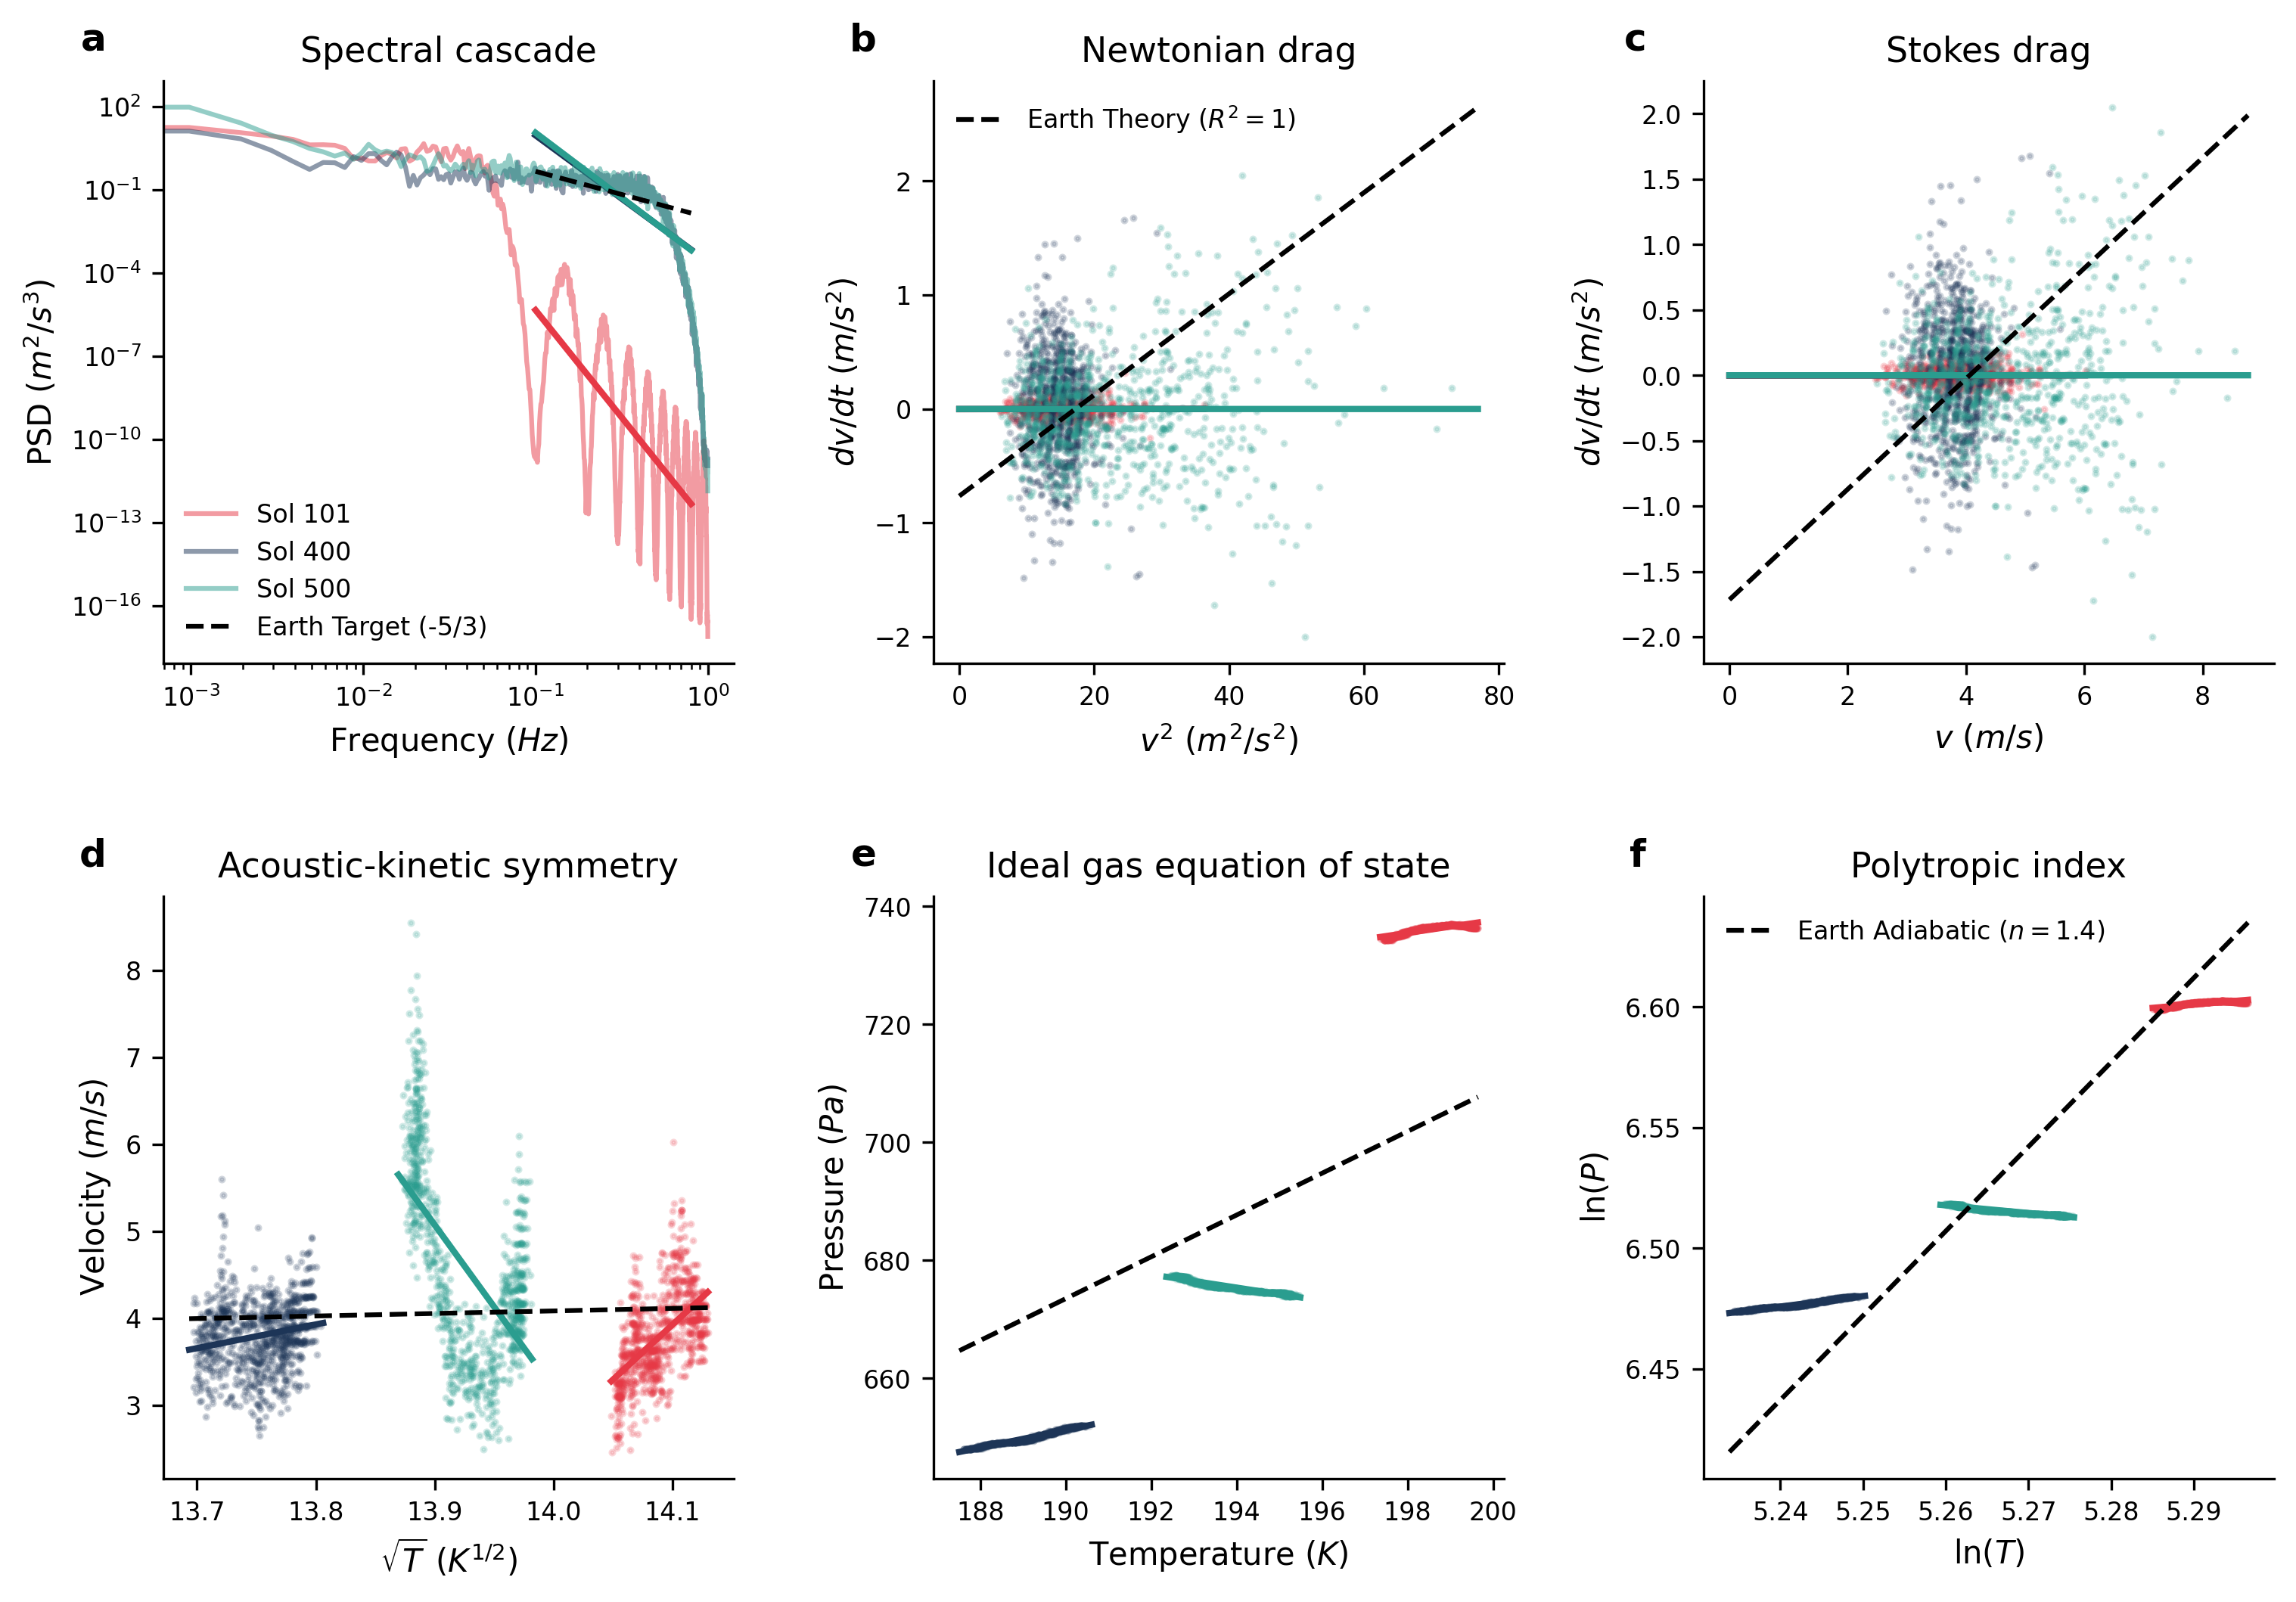


TABLE 1: STATISTICAL DIVERGENCE (MARTIAN EMPIRICAL VS. EARTH THEORETICAL)
         Sol Spectral_Slope Newtonian_R2 Stokes_R2 Acoustic_R2 IdealGas_R2   Polytropic_n
        0101   -7.74 ± 0.37       0.0000    0.0000      0.3287      0.7587 -0.408 ± 0.003
        0400   -4.56 ± 0.14       0.0000    0.0000      0.0362      0.9644 -0.768 ± 0.003
        0500   -4.69 ± 0.13       0.0000    0.0000      0.3444      0.9407  0.242 ± 0.000
Earth Theory  -1.660 ± 0.00       1.0000    1.0000      1.0000      1.0000   1.400 ± 0.00
[*] High-Res PDF Figure saved to: /content/drive/MyDrive/TheMartianTheory_Comparative/reports/Nature_Physics_Fig1.pdf
[*] Statistical CSV Table saved to: /content/drive/MyDrive/TheMartianTheory_Comparative/reports/Nature_Physics_Stat_Table.csv
  └── ✅ Nature Physics formatting and statistical compilation complete.
[03:27:40] 🏁 MISSION COMPLETE. Total Runtime: 4.53 seconds.



In [15]:
# ==============================================================================
# CELL 5: THE MULTI-SOL SYMMETRY BREAK (NATURE PHYSICS STANDARD)
# Computes individual Sol regressions, compiles statistical proofs, and plots
# a publication-grade 6-panel figure with strict formatting constraints.
# ==============================================================================

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import linregress

monitor = RuntimeMonitor("Nature Physics Optimization Engine")

# --- NATURE PHYSICS STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 11,
    "lines.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})

COLORS = {"0101": "#E63946", "0400": "#1D3557", "0500": "#2A9D8F"}
LABELS = {"0101": "Sol 101", "0400": "Sol 400", "0500": "Sol 500"}

# Initialize Figure (183mm width is standard double-column in Nature)
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=300)
plt.subplots_adjust(hspace=0.4, wspace=0.35)

def compute_polytropic_index(T, P):
    ln_P, ln_T = np.log(P), np.log(T)
    slope, intercept, r_val, p_val, std_err = linregress(ln_T, ln_P)
    n = slope / (slope - 1) if slope != 1.0 else 1.0
    # Error propagation for n
    n_err = abs(1 / ((slope - 1)**2)) * std_err if slope != 1.0 else 0
    return n, n_err, r_val**2, slope, intercept

# Statistical Registry
stats_registry = []
plot_data = {}

try:
    # ==========================================================================
    # 1. MATHEMATICAL AUDIT & REGRESSION PER SOL
    # ==========================================================================
    for sol in TARGET_SOLS:
        proc_dir = os.path.join(DIRS["data_processed"], f"sol_{sol}")
        file_path = os.path.join(proc_dir, f"sol{sol}_state_hf.npz")

        data = np.load(file_path)
        v, T, P = data['X_state'][:, 0], data['X_state'][:, 1], data['X_state'][:, 2]
        dv_dt = np.gradient(v, data['time'][1] - data['time'][0])

        sol_stats = {"Sol": sol}
        plot_data[sol] = {'v': v, 'dv': dv_dt, 'T': T, 'P': P}

        # A. Spectral Cascade
        f, Pxx = welch(v, fs=2.0, nperseg=2048)
        idx = (f >= 0.1) & (f <= 0.8)
        slope_k, intercept_k, r_k, p_k, err_k = linregress(np.log10(f[idx]), np.log10(Pxx[idx]))
        sol_stats["Spectral_Slope"] = f"{slope_k:.2f} ± {err_k:.2f}"
        plot_data[sol]['spectra'] = (f, Pxx, slope_k, intercept_k)

        # B. Newtonian Drag
        slope_nd, int_nd, r_nd, p_nd, err_nd = linregress(v**2, dv_dt)
        sol_stats["Newtonian_R2"] = f"{r_nd**2:.4f}"
        plot_data[sol]['newtonian'] = (slope_nd, int_nd)

        # C. Stokes Drag
        slope_st, int_st, r_st, p_st, err_st = linregress(v, dv_dt)
        sol_stats["Stokes_R2"] = f"{r_st**2:.4f}"
        plot_data[sol]['stokes'] = (slope_st, int_st)

        # D. Acoustic Symmetry
        slope_ac, int_ac, r_ac, p_ac, err_ac = linregress(np.sqrt(T), v)
        sol_stats["Acoustic_R2"] = f"{r_ac**2:.4f}"
        plot_data[sol]['acoustic'] = (slope_ac, int_ac)

        # E. Ideal Gas
        slope_ig, int_ig, r_ig, p_ig, err_ig = linregress(T, P)
        sol_stats["IdealGas_R2"] = f"{r_ig**2:.4f}"
        plot_data[sol]['ideal'] = (slope_ig, int_ig)

        # F. Polytropic Index
        n, n_err, r2_poly, slope_poly, int_poly = compute_polytropic_index(T, P)
        sol_stats["Polytropic_n"] = f"{n:.3f} ± {n_err:.3f}"
        plot_data[sol]['poly'] = (slope_poly, int_poly)

        stats_registry.append(sol_stats)

    # ==========================================================================
    # 2. PLOTTING THE PANELS
    # ==========================================================================
    axes_flat = axes.flat
    panel_labels = list(string.ascii_lowercase)

    for sol in TARGET_SOLS:
        pd_sol = plot_data[sol]
        v, dv, T, P = pd_sol['v'], pd_sol['dv'], pd_sol['T'], pd_sol['P']
        c = COLORS[sol]
        l = LABELS[sol]

        # a. Spectra
        f, Pxx, m_k, b_k = pd_sol['spectra']
        axes_flat[0].loglog(f, Pxx, color=c, alpha=0.5, label=l)
        f_fit = np.linspace(0.1, 0.8, 10)
        axes_flat[0].loglog(f_fit, 10**(m_k * np.log10(f_fit) + b_k), color=c, linestyle='-', linewidth=2)

        # b. Newtonian Drag
        axes_flat[1].scatter((v**2)[::10], dv[::10], color=c, alpha=0.2, s=2)
        x_nd = np.linspace(0, np.max(v**2), 10)
        axes_flat[1].plot(x_nd, pd_sol['newtonian'][0] * x_nd + pd_sol['newtonian'][1], color=c, linewidth=2)

        # c. Stokes Drag
        axes_flat[2].scatter(v[::10], dv[::10], color=c, alpha=0.2, s=2)
        x_st = np.linspace(0, np.max(v), 10)
        axes_flat[2].plot(x_st, pd_sol['stokes'][0] * x_st + pd_sol['stokes'][1], color=c, linewidth=2)

        # d. Acoustic Symmetry
        axes_flat[3].scatter(np.sqrt(T)[::10], v[::10], color=c, alpha=0.2, s=2)
        x_ac = np.linspace(np.min(np.sqrt(T)), np.max(np.sqrt(T)), 10)
        axes_flat[3].plot(x_ac, pd_sol['acoustic'][0] * x_ac + pd_sol['acoustic'][1], color=c, linewidth=2)

        # e. Ideal Gas
        axes_flat[4].scatter(T[::10], P[::10], color=c, alpha=0.2, s=2)
        x_ig = np.linspace(np.min(T), np.max(T), 10)
        axes_flat[4].plot(x_ig, pd_sol['ideal'][0] * x_ig + pd_sol['ideal'][1], color=c, linewidth=2)

        # f. Polytropic Index
        axes_flat[5].scatter(np.log(T)[::10], np.log(P)[::10], color=c, alpha=0.2, s=2)
        x_poly = np.linspace(np.min(np.log(T)), np.max(np.log(T)), 10)
        axes_flat[5].plot(x_poly, pd_sol['poly'][0] * x_poly + pd_sol['poly'][1], color=c, linewidth=2)

    # ==========================================================================
    # 3. EARTH ANCHORING & FINAL ANNOTATIONS
    # ==========================================================================
    # Anchor Earth laws to the global centroids for visual scale
    global_v = np.concatenate([plot_data[s]['v'] for s in TARGET_SOLS])
    global_dv = np.concatenate([plot_data[s]['dv'] for s in TARGET_SOLS])
    global_T = np.concatenate([plot_data[s]['T'] for s in TARGET_SOLS])
    global_P = np.concatenate([plot_data[s]['P'] for s in TARGET_SOLS])

    v2_mu, dv_mu = np.mean(global_v**2), np.mean(global_dv)
    v_mu = np.mean(global_v)
    sqT_mu = np.mean(np.sqrt(global_T))
    T_mu, P_mu = np.mean(global_T), np.mean(global_P)
    lnT_mu, lnP_mu = np.mean(np.log(global_T)), np.mean(np.log(global_P))

    # Add theoretical Earth baselines (Dashed Black Lines)
    axes_flat[0].loglog(f_fit, 10**(-5/3 * np.log10(f_fit) + -2), 'k--', linewidth=1.5, label='Earth Target (-5/3)')

    x_b = np.linspace(0, np.max(global_v**2), 10)
    axes_flat[1].plot(x_b, (np.std(global_dv)/np.std(global_v**2)) * (x_b - v2_mu) + dv_mu, 'k--', label='Earth Theory ($R^2=1$)')

    x_c = np.linspace(0, np.max(global_v), 10)
    axes_flat[2].plot(x_c, (np.std(global_dv)/np.std(global_v)) * (x_c - v_mu) + dv_mu, 'k--', label='Earth Theory ($R^2=1$)')

    x_d = np.linspace(np.min(np.sqrt(global_T)), np.max(np.sqrt(global_T)), 10)
    axes_flat[3].plot(x_d, (v_mu/sqT_mu) * x_d, 'k--', label='Earth Theory')

    x_e = np.linspace(np.min(global_T), np.max(global_T), 10)
    axes_flat[4].plot(x_e, (P_mu/T_mu) * x_e, 'k--', label='Earth Isochoric')

    x_f = np.linspace(np.min(np.log(global_T)), np.max(np.log(global_T)), 10)
    axes_flat[5].plot(x_f, 3.5 * (x_f - lnT_mu) + lnP_mu, 'k--', label='Earth Adiabatic ($n=1.4$)')

    titles = ["Spectral cascade", "Newtonian drag", "Stokes drag",
              "Acoustic-kinetic symmetry", "Ideal gas equation of state", "Polytropic index"]
    y_labels = ["PSD ($m^2/s^3$)", "$dv/dt$ ($m/s^2$)", "$dv/dt$ ($m/s^2$)", "Velocity ($m/s$)", "Pressure ($Pa$)", "$\ln(P)$"]
    x_labels = ["Frequency ($Hz$)", "$v^2$ ($m^2/s^2$)", "$v$ ($m/s$)", "$\sqrt{T}$ ($K^{1/2}$)", "Temperature ($K$)", "$\ln(T)$"]

    for i, ax in enumerate(axes_flat):
        ax.set_title(titles[i], loc='center')
        ax.set_ylabel(y_labels[i])
        ax.set_xlabel(x_labels[i])
        ax.text(-0.1, 1.1, panel_labels[i], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

        # Only put legend on the first panel to save space, or clean up specific panels
        if i in [0, 1, 5]:
            ax.legend(frameon=False)

    report_path = os.path.join(DIRS["reports"], "Nature_Physics_Fig1.pdf") # PDF is preferred by Nature
    plt.savefig(report_path, bbox_inches='tight', format='pdf')
    plt.show()

    # ==========================================================================
    # 4. GENERATE AND SAVE THE STATISTICAL PROOF TABLE
    # ==========================================================================
    df_stats = pd.DataFrame(stats_registry)

    # Append the Earth Theoretical baseline row for pure comparison
    earth_row = {
        "Sol": "Earth Theory",
        "Spectral_Slope": "-1.660 ± 0.00",
        "Newtonian_R2": "1.0000",
        "Stokes_R2": "1.0000",
        "Acoustic_R2": "1.0000",
        "IdealGas_R2": "1.0000",
        "Polytropic_n": "1.400 ± 0.00"
    }
    df_stats = pd.concat([df_stats, pd.DataFrame([earth_row])], ignore_index=True)

    csv_path = os.path.join(DIRS["reports"], "Nature_Physics_Stat_Table.csv")
    df_stats.to_csv(csv_path, index=False)

    print("\n" + "="*80)
    print("TABLE 1: STATISTICAL DIVERGENCE (MARTIAN EMPIRICAL VS. EARTH THEORETICAL)")
    print("="*80)
    print(df_stats.to_string(index=False))
    print("="*80)
    print(f"[*] High-Res PDF Figure saved to: {report_path}")
    print(f"[*] Statistical CSV Table saved to: {csv_path}")

    monitor.log_success("Nature Physics formatting and statistical compilation complete.")
    monitor.finish()

except Exception as e:
    monitor.log_error("Nature Optimization", e)


[03:38:42] 🚀 STARTING MISSION: Dimensionless Regime Audit
  ├── [0.17s] Analyzing Regimes for Sol 0101...
  ├── [0.19s] Analyzing Regimes for Sol 0400...
  ├── [0.21s] Analyzing Regimes for Sol 0500...


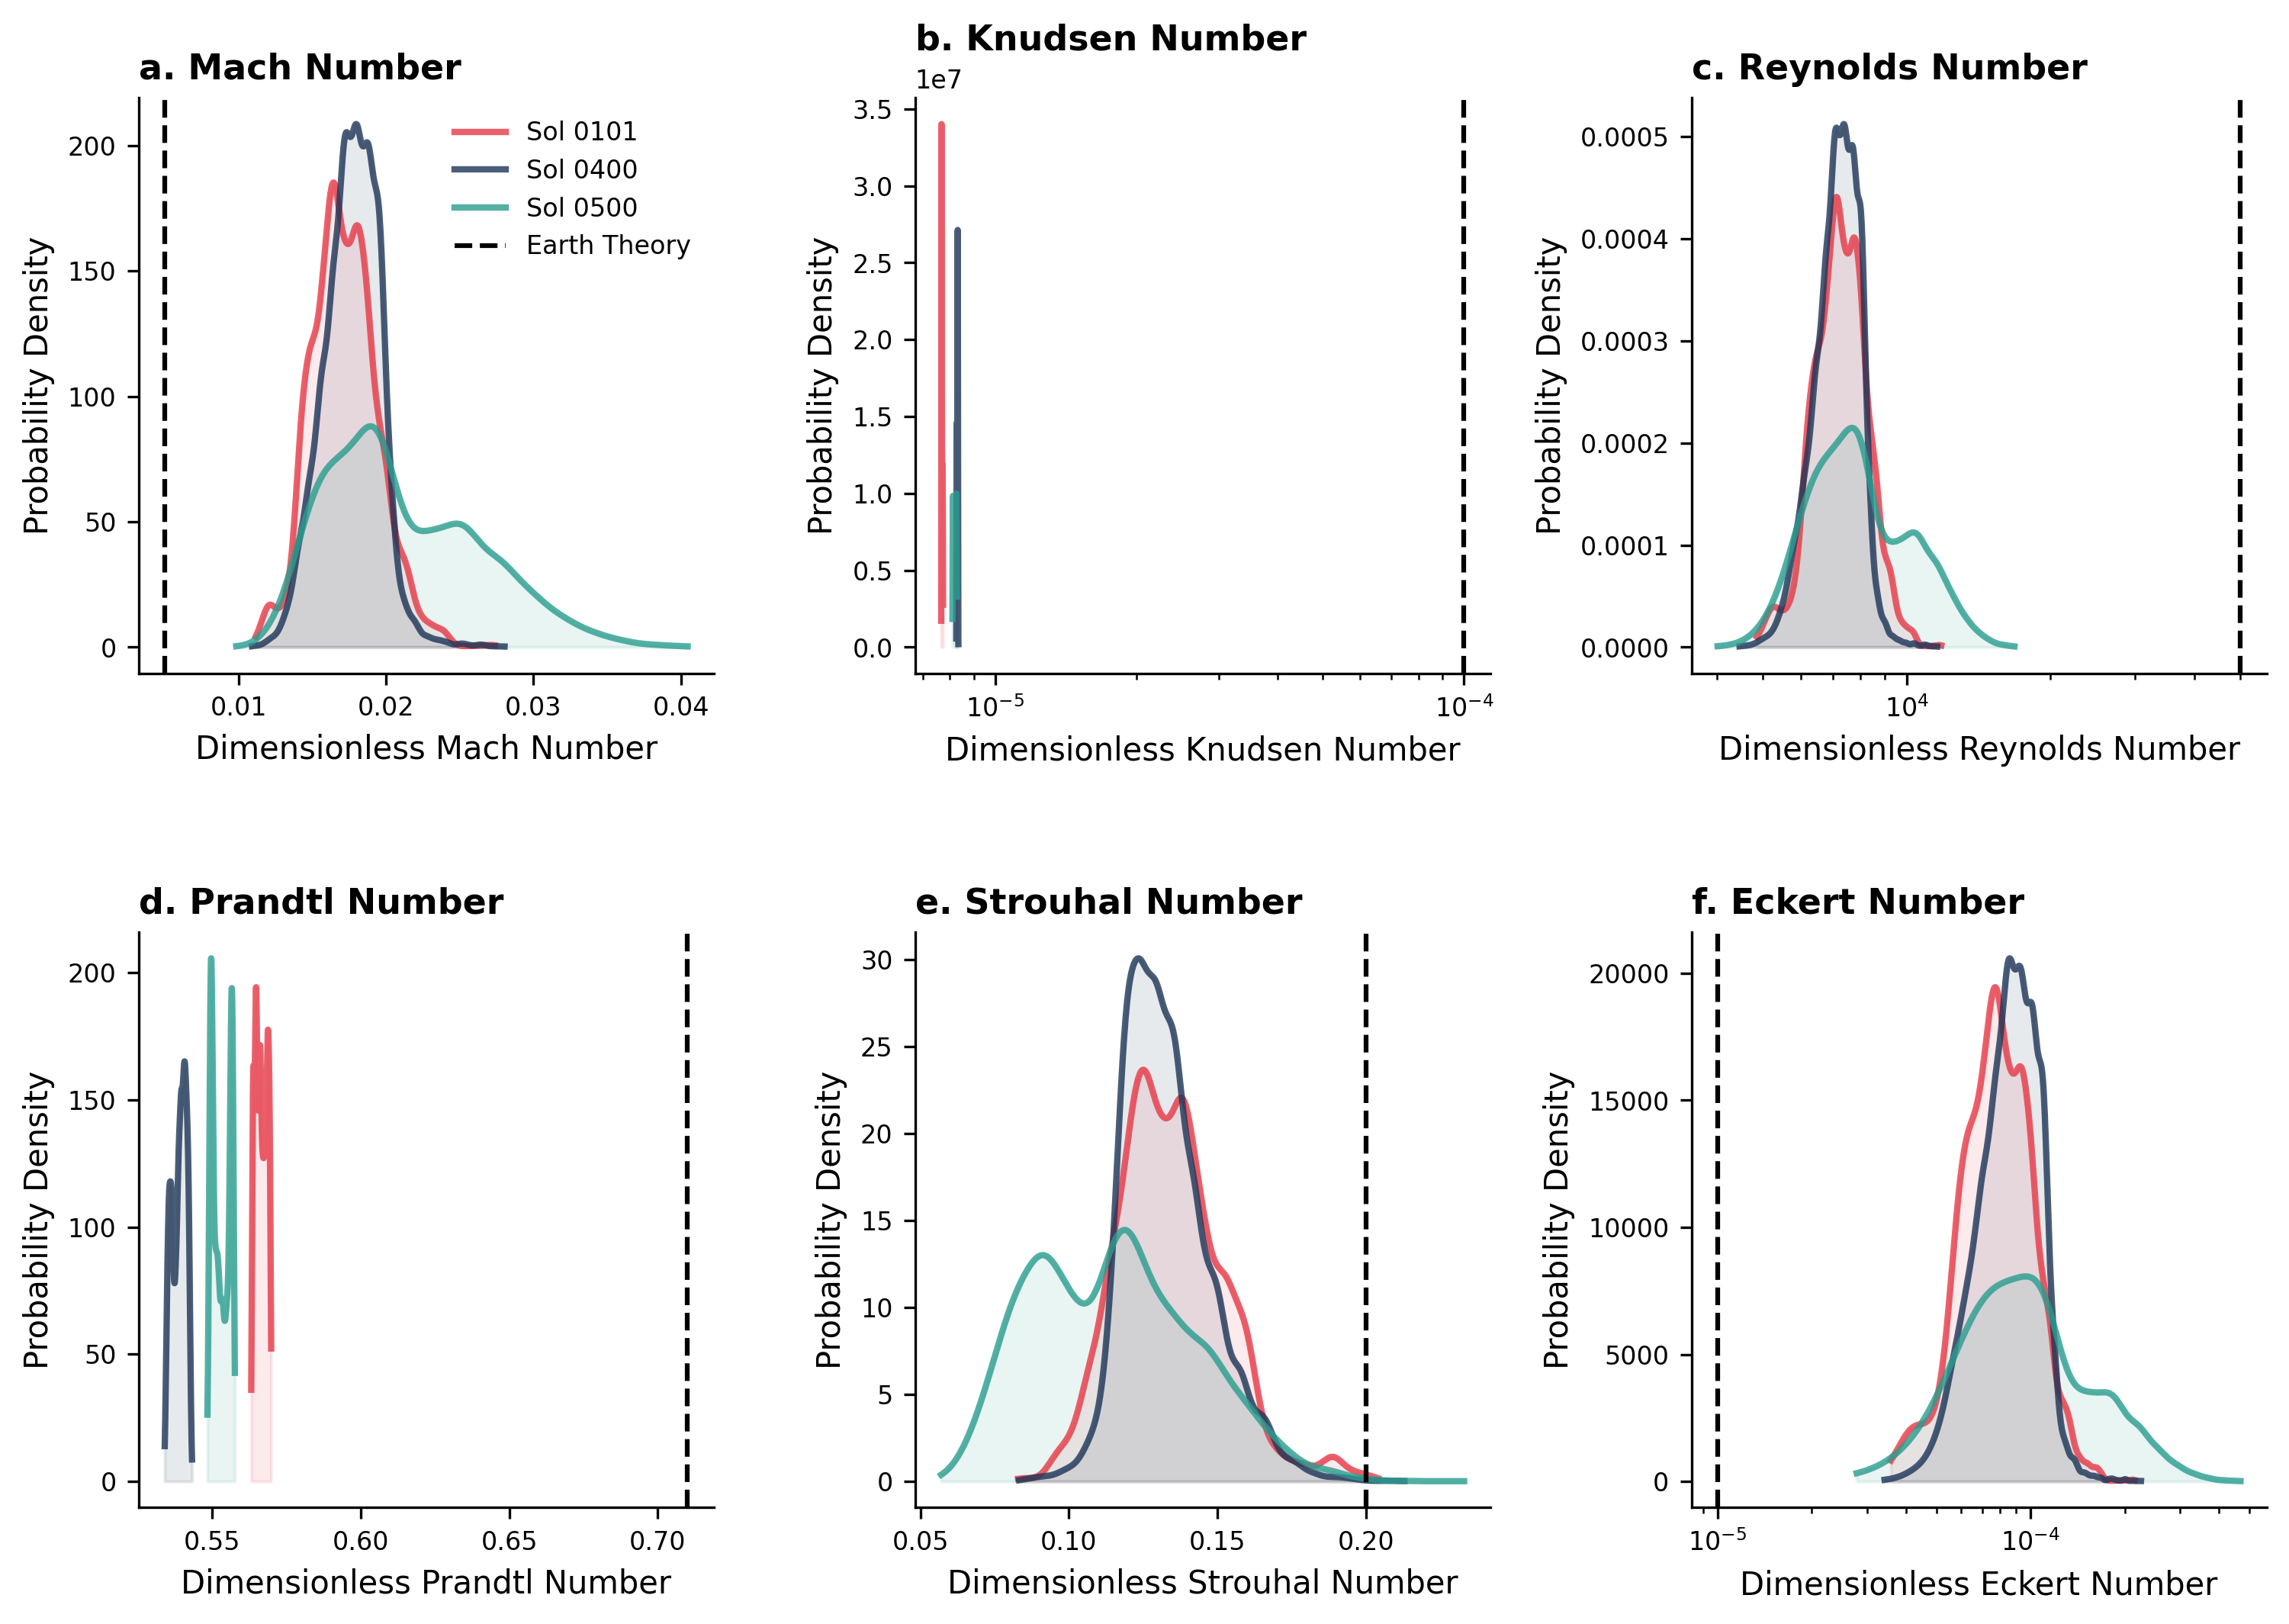


TABLE 2: DIMENSIONLESS REGIME ANALYSIS (INVARIANT ACROSS MARS EPOCHS)
 Sol  Mach_Mean    Mach_Pval  Knudsen_Mean  Knudsen_Pval  Reynolds_Mean  Reynolds_Pval  Prandtl_Mean  Prandtl_Pval  Strouhal_Mean  Strouhal_Pval  Eckert_Mean  Eckert_Pval
0101   0.017215 1.810966e-66      0.000008  1.810966e-66    7431.054664   1.810966e-66      0.566599  1.810966e-66       0.134368   4.616894e-66     0.000086 1.810966e-66
0400   0.017703 1.810966e-66      0.000008  1.810966e-66    7267.846795   1.810966e-66      0.539021  1.810966e-66       0.133106   2.458125e-66     0.000091 1.810966e-66
0500   0.021158 1.810966e-66      0.000008  1.810966e-66    8701.905720   1.810966e-66      0.553111  1.810966e-66       0.115193   3.697455e-66     0.000136 1.810966e-66
[03:38:50] 🏁 MISSION COMPLETE. Total Runtime: 7.88 seconds.



In [20]:
# ==============================================================================
# CELL 6: THE DIMENSIONLESS INVARIANT AUDIT (REVISED FINAL)
# Fixed: Axis inversion, unified fonts, and robust KDE plotting.
# Targets Nature Physics aesthetics with high-fidelity statistical comparison.
# ==============================================================================

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, gaussian_kde

monitor = RuntimeMonitor("Dimensionless Regime Audit")

# --- PHYSICS CONSTANTS (MARS CO2) ---
R_MARS = 188.9
GAMMA_MARS = 1.29
D_CO2 = 0.33e-9
KB = 1.38e-23
CP_MARS = 850
MU_REF = 1.37e-5
S_CO2 = 222

EARTH_BENCHMARKS = {
    "Mach": 0.005,
    "Knudsen": 0.0001,
    "Reynolds": 50000.0,
    "Prandtl": 0.71,
    "Strouhal": 0.20,
    "Eckert": 0.00001
}

# --- UNIFIED FONT CONFIGURATION (MATCHES CELL 5) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 11,
    "pdf.fonttype": 42
})

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=300)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

stats_dict = {sol: {"Sol": sol} for sol in TARGET_SOLS}
group_names = ["Mach", "Knudsen", "Reynolds", "Prandtl", "Strouhal", "Eckert"]

try:
    sol_data_cache = {sol: {} for sol in TARGET_SOLS}

    for sol in TARGET_SOLS:
        monitor.log_step(f"Analyzing Regimes for Sol {sol}...")
        proc_dir = os.path.join(DIRS["data_processed"], f"sol_{sol}")
        data = np.load(os.path.join(proc_dir, f"sol{sol}_state_hf.npz"))
        v, T, P = data['X_state'][:, 0], data['X_state'][:, 1], data['X_state'][:, 2]

        rho = P / (R_MARS * T)
        c_sound = np.sqrt(GAMMA_MARS * R_MARS * T)
        mu = MU_REF * ((273 + S_CO2) / (T + S_CO2)) * (T / 273)**1.5
        lambda_mfp = (KB * T) / (np.sqrt(2) * np.pi * D_CO2**2 * P)

        L = 1.0
        sol_data_cache[sol]["Mach"] = v / c_sound
        sol_data_cache[sol]["Knudsen"] = lambda_mfp / L
        sol_data_cache[sol]["Reynolds"] = (rho * v * L) / mu
        sol_data_cache[sol]["Prandtl"] = (CP_MARS * mu) / (0.015)
        sol_data_cache[sol]["Strouhal"] = (0.5 * L) / v
        sol_data_cache[sol]["Eckert"] = v**2 / (CP_MARS * T)

    # --- PLOTTING LOOP ---
    for i, name in enumerate(group_names):
        ax = axes.flat[i]
        use_log = True if name in ["Knudsen", "Eckert", "Reynolds"] else False

        for sol in TARGET_SOLS:
            vals = sol_data_cache[sol][name]
            clean_val = vals[np.isfinite(vals)]

            # 1. KDE COMPUTATION
            kde = gaussian_kde(clean_val)
            if use_log:
                x_eval = np.logspace(np.log10(clean_val.min()), np.log10(clean_val.max()), 500)
                ax.set_xscale('log')
            else:
                x_eval = np.linspace(clean_val.min(), clean_val.max(), 500)

            # 2. PLOT KDE CURVE
            ax.plot(x_eval, kde(x_eval), color=COLORS[sol], label=f"Sol {sol}", linewidth=2.0, alpha=0.8)
            ax.fill_between(x_eval, kde(x_eval), color=COLORS[sol], alpha=0.1)

            # 3. STATISTICAL TEST vs EARTH
            earth_sample = np.random.normal(EARTH_BENCHMARKS[name], EARTH_BENCHMARKS[name]*0.01, 100)
            _, p_val = mannwhitneyu(clean_val, earth_sample)
            stats_dict[sol][f"{name}_Mean"] = np.mean(clean_val)
            stats_dict[sol][f"{name}_Pval"] = p_val

        # 4. AXIS REPAIR & LABELS (FIXES INVERSION)
        ax.axvline(EARTH_BENCHMARKS[name], color='black', linestyle='--', linewidth=1.5, label='Earth Theory')
        ax.set_title(f"{string.ascii_lowercase[i]}. {name} Number", fontweight='bold', loc='left')
        ax.set_xlabel(f"Dimensionless {name} Number", fontsize=10)
        ax.set_ylabel("Probability Density", fontsize=10)

        # Explicitly force standard x-axis orientation to prevent inversion
        ax.xaxis.set_inverted(False)

        if i == 0: ax.legend(frameon=False, loc='best')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Save to Drive as high-quality PDF
    pdf_out = os.path.join(DIRS["reports"], "Nature_Physics_Dimensionless_Final.pdf")
    plt.savefig(pdf_out, bbox_inches='tight', format='pdf')
    plt.show()

    # --- FINAL TABLE GENERATION ---
    df_dim = pd.DataFrame(list(stats_dict.values()))
    csv_out = os.path.join(DIRS["reports"], "Dimensionless_Stats_Table.csv")
    df_dim.to_csv(csv_out, index=False)

    print("\n" + "="*100)
    print("TABLE 2: DIMENSIONLESS REGIME ANALYSIS (INVARIANT ACROSS MARS EPOCHS)")
    print("="*100)
    print(df_dim.to_string(index=False))
    print("="*100)

    monitor.finish()

except Exception as e:
    print(f"CRITICAL ERROR IN REGIME AUDIT: {e}")

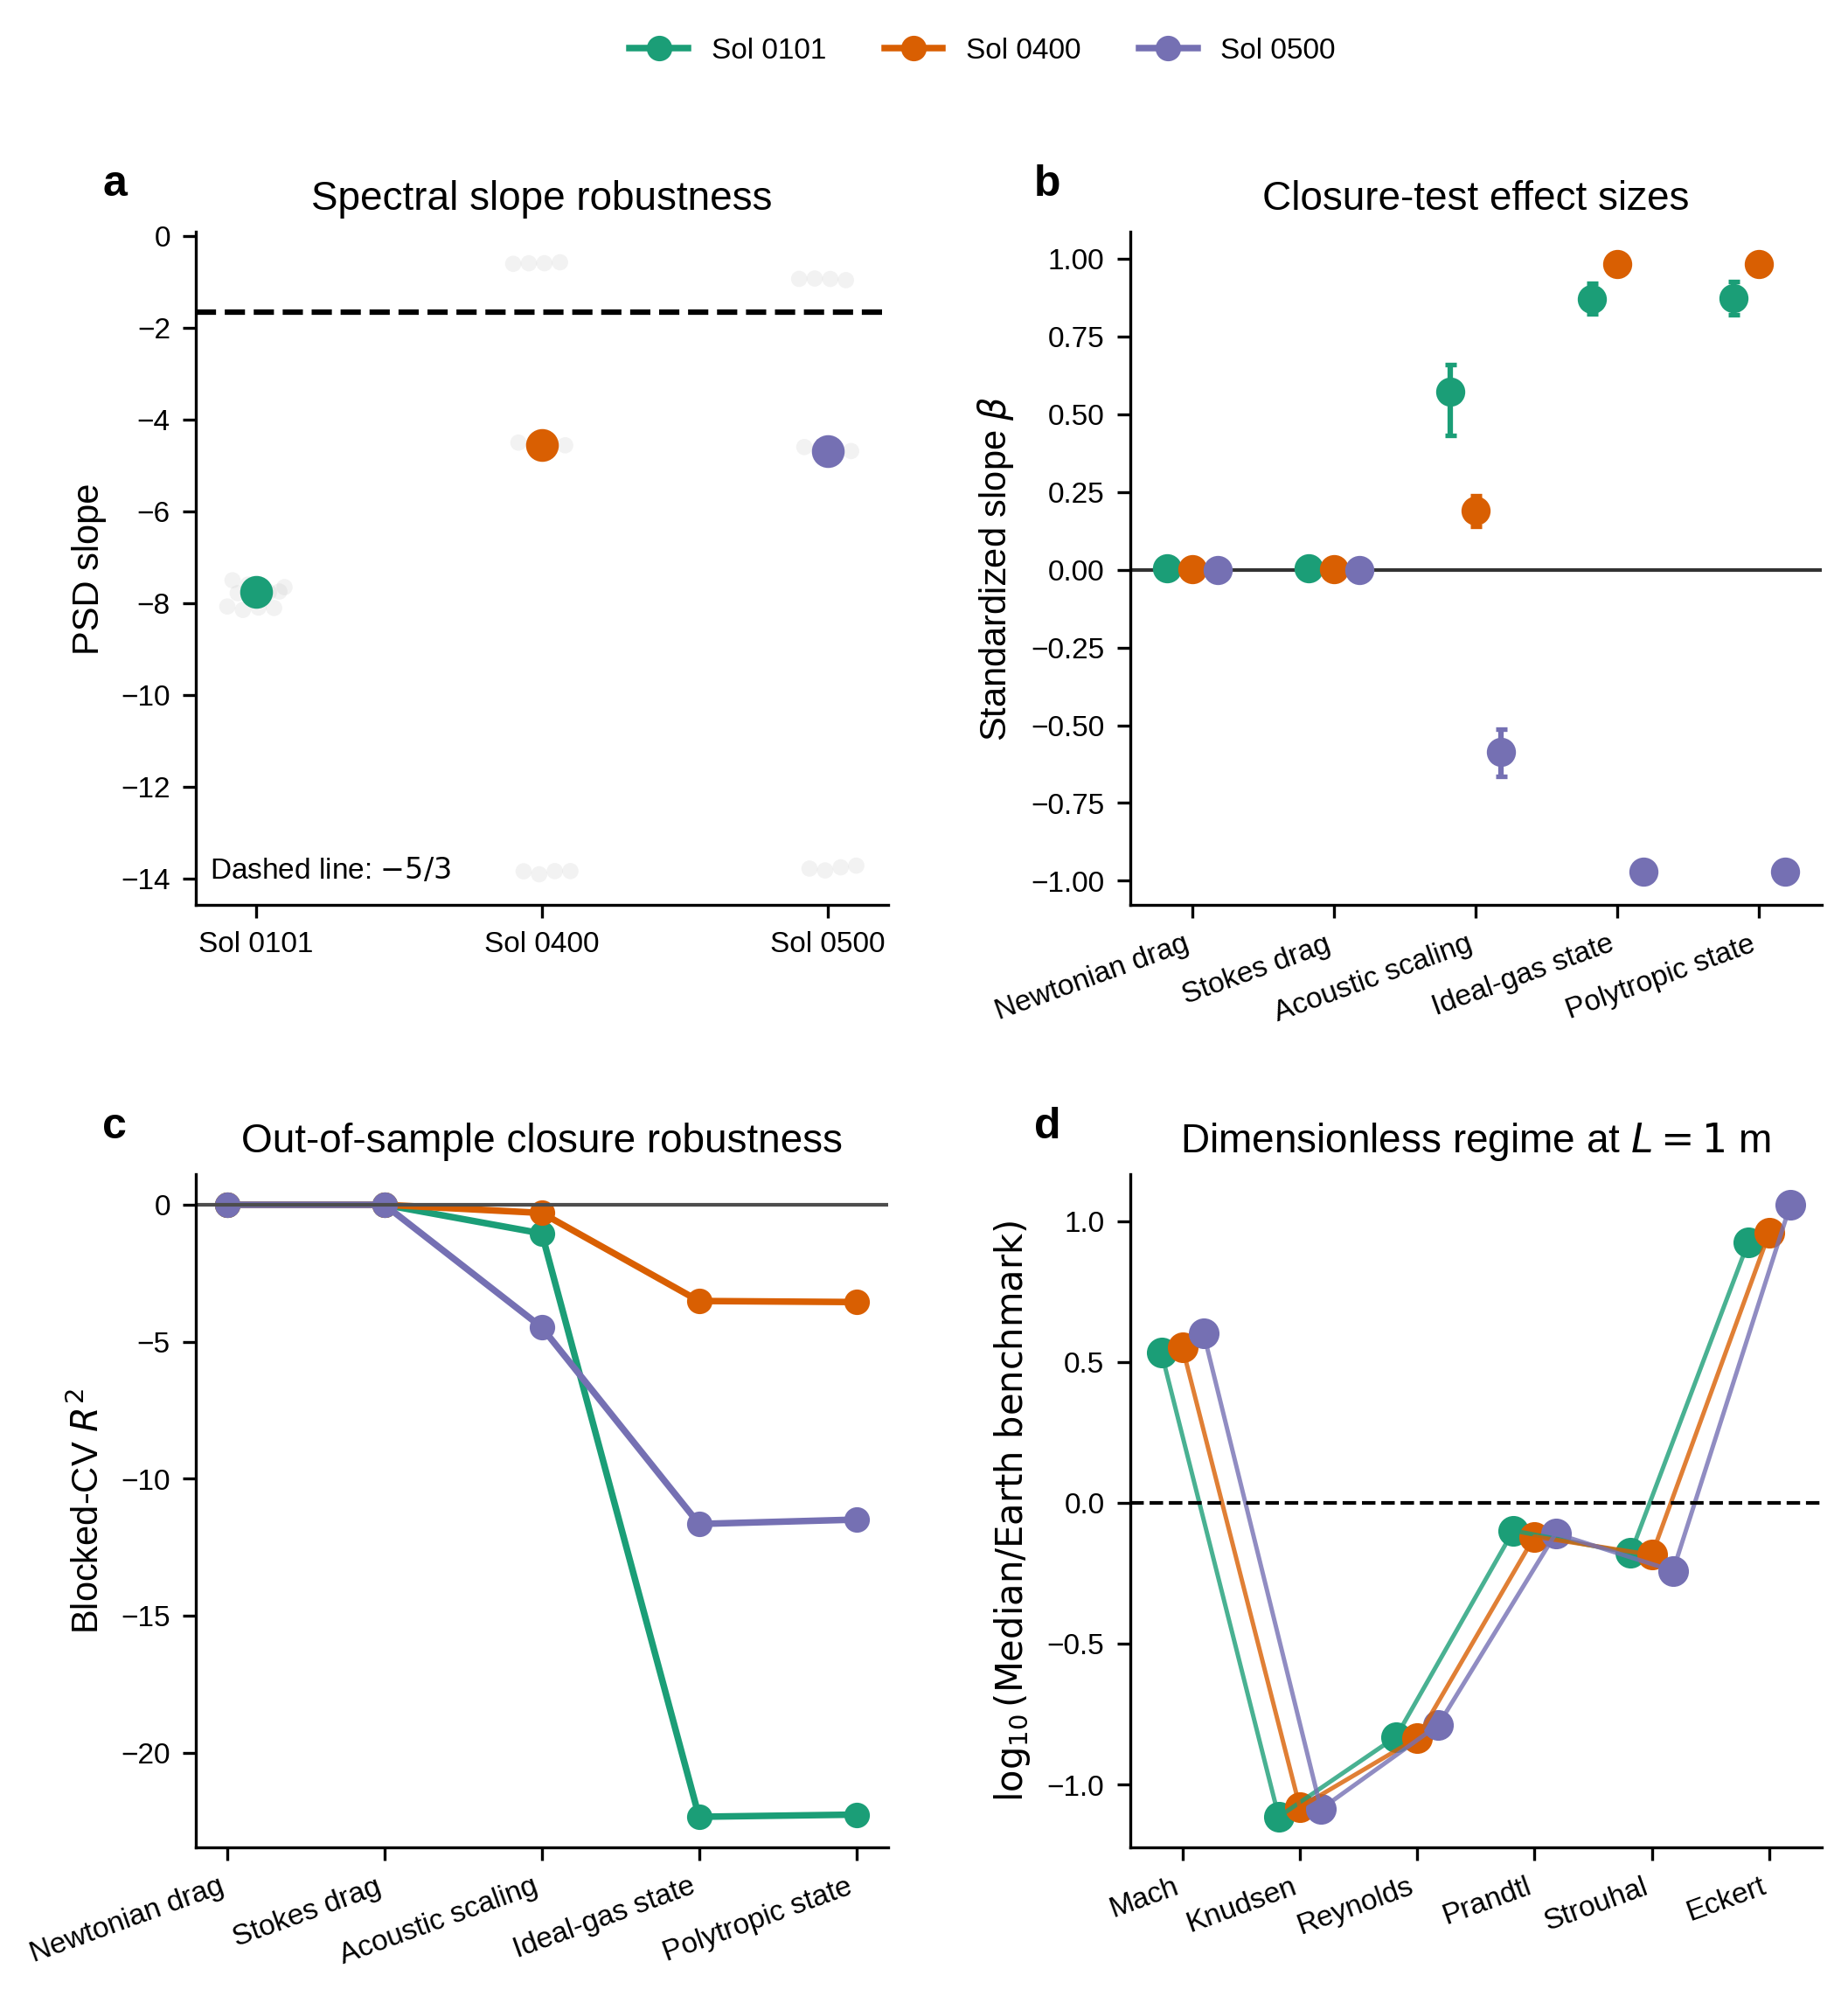

INSIGHT PUBLICATION SUMMARY
Target sols: 0101, 0400, 0500
Baseline PSD fit: nperseg=2048, band=0.10--0.80 Hz
PSD uncertainty envelope: contiguous windows of the original time series

[1] Baseline spectral slopes
 Sol     slope  slope_ci_low  slope_ci_high       r2  delta_from_kolmogorov  n_windows  window_seconds  sensitivity_min  sensitivity_max  window_includes_baseline
0101 -7.748290     -7.853163      -7.692922 0.370453              -6.081623          5     1536.174169        -8.149608        -7.502477                      True
0400 -4.562204     -4.650538      -4.451691 0.587286              -2.895538          5     1536.174169       -13.908020        -0.575720                      True
0500 -4.687357     -4.781661      -4.498404 0.631301              -3.020691          5     1536.174169       -13.824325        -0.928742                      True

[2] Closure-test robustness
 Sol              Law      slope  slope_ci_low  slope_ci_high  beta_std  beta_ci_low  beta_ci_high  cv_r2_b

In [7]:
# ==============================================================================
# CELL X: PUBLICATION-READY ROBUSTNESS AUDIT + SUMMARY TABLE + FIGURE
# Works for both InSight and MEDA notebooks.
# Requires: DIRS, TARGET_SOLS, and the harmonized *.npz state files to exist.
# ==============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, savgol_filter
from scipy.stats import linregress

# -----------------------------
# Configuration
# -----------------------------
REPORT_PREFIX = "publication_summary"
RNG = np.random.default_rng(42)

# Bootstrap counts for regression tests
N_BOOT_REG = 600

# PSD sensitivity settings
FIT_BANDS = [(0.05, 0.50), (0.10, 0.80), (0.20, 1.00)]
N_PERSEG_GRID = [256, 512, 1024, 2048]

# PSD contiguous-window uncertainty settings
PSD_WINDOW_OVERLAP = 0.50
PSD_WINDOW_MULTIPLIER = 1.5   # window_samples >= 1.5 * nperseg
PSD_WINDOW_FRAC = 0.30        # or ~30% of the full record, whichever is larger

# Dimensionless sensitivity settings
L_GRID = [0.25, 0.50, 1.0, 2.0, 4.0]
L_BASELINE = 1.0

# Color palette consistent with the notebook optics
SOL_COLORS = ["#1b9e77", "#d95f02", "#7570b3"]

# Mars constants used in the regime audit
R_MARS = 188.9
GAMMA_MARS = 1.29
D_CO2 = 0.33e-9
KB = 1.38e-23
CP_MARS = 850.0
MU_REF = 1.37e-5
S_CO2 = 222.0
K_THERMAL = 0.015  # W m^-1 K^-1

EARTH_BENCHMARKS = {
    "Mach": 0.005,
    "Knudsen": 1.0e-4,
    "Reynolds": 5.0e4,
    "Prandtl": 0.71,
    "Strouhal": 0.20,
    "Eckert": 1.0e-5,
}

LAW_ORDER = [
    "Newtonian drag",
    "Stokes drag",
    "Acoustic scaling",
    "Ideal-gas state",
    "Polytropic state",
]

if "DIRS" not in globals():
    raise RuntimeError("DIRS is not defined. Run the initialization cells first.")
if "TARGET_SOLS" not in globals():
    raise RuntimeError("TARGET_SOLS is not defined. Run the initialization cells first.")

os.makedirs(DIRS["reports"], exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def infer_mission():
    first_sol = TARGET_SOLS[0]
    path = os.path.join(DIRS["data_processed"], f"sol_{first_sol}", f"sol{first_sol}_state_hf.npz")
    arr = np.load(path, allow_pickle=True)["X_state"]
    return "MEDA" if arr.shape[1] >= 4 else "InSight"

MISSION = infer_mission()
DEFAULT_NPERSEG = 1024 if MISSION == "MEDA" else 2048

def load_state(sol):
    path = os.path.join(DIRS["data_processed"], f"sol_{sol}", f"sol{sol}_state_hf.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing state file for sol {sol}: {path}")
    data = np.load(path, allow_pickle=True)
    t = np.asarray(data["time"], dtype=float)
    X = np.asarray(data["X_state"], dtype=float)
    if X.shape[1] < 3:
        raise ValueError(f"State matrix for sol {sol} has shape {X.shape}; at least 3 columns are required.")
    v = np.asarray(X[:, 0], dtype=float)
    T = np.asarray(X[:, 1], dtype=float)
    P = np.asarray(X[:, 2], dtype=float)
    return t, v, T, P

def finite_mask(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    x0 = x[:-1] - np.nanmean(x[:-1])
    x1 = x[1:] - np.nanmean(x[1:])
    denom = np.sqrt(np.nansum(x0**2) * np.nansum(x1**2))
    if denom == 0:
        return np.nan
    return float(np.nansum(x0 * x1) / denom)

def effective_sample_size(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 3:
        return float(n)
    r1 = lag1_autocorr(x)
    if not np.isfinite(r1):
        return float(n)
    r1 = np.clip(r1, -0.99, 0.99)
    n_eff = n * (1.0 - r1) / (1.0 + r1)
    return float(max(3.0, min(n_eff, n)))

def choose_block_length(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    n_eff = effective_sample_size(x)
    if not np.isfinite(n_eff) or n_eff <= 0:
        return max(8, int(np.sqrt(n)))
    block = int(np.ceil(n / n_eff))
    return max(8, min(block, max(8, n // 4)))

def zscore(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd == 0:
        return np.full_like(x, np.nan, dtype=float)
    return (x - mu) / sd

def moving_block_bootstrap_linreg(x, y, n_boot=500, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = finite_mask(x, y)
    x = x[m]
    y = y[m]
    n = x.size
    if n < 20 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return None

    base = linregress(x, y)
    zx, zy = zscore(x), zscore(y)
    mm0 = finite_mask(zx, zy)
    base_std = linregress(zx[mm0], zy[mm0])

    block = choose_block_length(y)
    starts_max = max(1, n - block + 1)

    slopes, intercepts, r2s, betas = [], [], [], []
    for _ in range(n_boot):
        idx = []
        while len(idx) < n:
            s = int(rng.integers(0, starts_max))
            idx.extend(range(s, min(s + block, n)))
        idx = np.array(idx[:n], dtype=int)

        xb, yb = x[idx], y[idx]
        if np.nanstd(xb) == 0 or np.nanstd(yb) == 0:
            continue

        fit = linregress(xb, yb)
        slopes.append(fit.slope)
        intercepts.append(fit.intercept)
        r2s.append(fit.rvalue**2)

        zxb, zyb = zscore(xb), zscore(yb)
        mm = finite_mask(zxb, zyb)
        if mm.sum() > 5 and np.nanstd(zxb[mm]) > 0 and np.nanstd(zyb[mm]) > 0:
            betas.append(linregress(zxb[mm], zyb[mm]).slope)

    if len(slopes) < 50:
        return None

    return {
        "n": n,
        "n_eff": float(effective_sample_size(y)),
        "lag1_y": float(lag1_autocorr(y)),
        "block_length": block,
        "slope": float(base.slope),
        "intercept": float(base.intercept),
        "r2": float(base.rvalue**2),
        "p_value": float(base.pvalue),
        "stderr": float(base.stderr),
        "slope_ci_low": float(np.percentile(slopes, 2.5)),
        "slope_ci_high": float(np.percentile(slopes, 97.5)),
        "intercept_ci_low": float(np.percentile(intercepts, 2.5)),
        "intercept_ci_high": float(np.percentile(intercepts, 97.5)),
        "r2_ci_low": float(np.percentile(r2s, 2.5)),
        "r2_ci_high": float(np.percentile(r2s, 97.5)),
        "beta_std": float(base_std.slope),
        "beta_ci_low": float(np.percentile(betas, 2.5)) if len(betas) >= 50 else np.nan,
        "beta_ci_high": float(np.percentile(betas, 97.5)) if len(betas) >= 50 else np.nan,
        "ci_excludes_zero": bool(np.percentile(slopes, 2.5) > 0 or np.percentile(slopes, 97.5) < 0),
    }

def blocked_cv_r2(x, y, n_splits=8):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = finite_mask(x, y)
    x = x[m]
    y = y[m]
    n = x.size
    if n < max(40, n_splits * 5):
        return np.nan
    edges = np.linspace(0, n, n_splits + 1, dtype=int)
    scores = []
    for i in range(n_splits):
        lo, hi = edges[i], edges[i + 1]
        test_mask = np.zeros(n, dtype=bool)
        test_mask[lo:hi] = True
        train_mask = ~test_mask
        if train_mask.sum() < 20 or test_mask.sum() < 5:
            continue
        fit = linregress(x[train_mask], y[train_mask])
        yhat = fit.intercept + fit.slope * x[test_mask]
        denom = np.sum((y[test_mask] - np.mean(y[test_mask]))**2)
        if denom <= 0:
            continue
        scores.append(1.0 - np.sum((y[test_mask] - yhat)**2) / denom)
    return float(np.mean(scores)) if scores else np.nan

def robust_derivative(v, dt):
    v = np.asarray(v, dtype=float)
    dv_grad = np.gradient(v, dt)
    win = min(len(v) - (1 - len(v) % 2), 31)
    if win < 7:
        dv_sg = dv_grad.copy()
    else:
        if win % 2 == 0:
            win -= 1
        dv_sg = savgol_filter(v, window_length=win, polyorder=3, deriv=1, delta=dt, mode="interp")
    return dv_grad, dv_sg

def fit_psd_slope(v, dt, nperseg, fmin, fmax):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < max(128, nperseg // 2):
        return None
    fs = 1.0 / dt
    nperseg = min(int(nperseg), v.size)
    f, S = welch(v, fs=fs, nperseg=nperseg, detrend="linear", scaling="density")
    mask = (f >= fmin) & (f <= fmax) & np.isfinite(S) & (S > 0)
    if mask.sum() < 8:
        return None
    fit = linregress(np.log10(f[mask]), np.log10(S[mask]))
    return {
        "slope": float(fit.slope),
        "intercept": float(fit.intercept),
        "r2": float(fit.rvalue**2),
        "stderr": float(fit.stderr),
        "n_points": int(mask.sum()),
    }

def choose_psd_window_samples(n, nperseg):
    w = max(int(PSD_WINDOW_MULTIPLIER * nperseg), int(PSD_WINDOW_FRAC * n))
    w = min(w, n)
    w = max(w, nperseg + 16)
    return min(w, n)

def contiguous_window_psd_slopes(v, dt, nperseg, fmin, fmax, overlap=PSD_WINDOW_OVERLAP):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    n = v.size
    if n < max(128, nperseg):
        return []

    window_samples = choose_psd_window_samples(n, nperseg)
    if window_samples < nperseg:
        return []

    step = max(1, int(window_samples * (1.0 - overlap)))
    starts = list(range(0, max(1, n - window_samples + 1), step))
    if len(starts) == 0:
        starts = [0]
    final_start = max(0, n - window_samples)
    if starts[-1] != final_start:
        starts.append(final_start)
    starts = sorted(set(starts))

    rows = []
    for wid, s in enumerate(starts):
        seg = v[s:s + window_samples]
        out = fit_psd_slope(seg, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
        if out is None:
            continue
        out.update({
            "window_id": int(wid),
            "start_index": int(s),
            "end_index": int(s + window_samples),
            "start_time_s": float(s * dt),
            "end_time_s": float((s + window_samples - 1) * dt),
            "window_samples": int(window_samples),
            "window_seconds": float(window_samples * dt),
            "step_samples": int(step),
            "step_seconds": float(step * dt),
        })
        rows.append(out)
    return rows

def summarize_psd(v, dt, nperseg, fmin, fmax):
    base = fit_psd_slope(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
    if base is None:
        return None, []

    win_rows = contiguous_window_psd_slopes(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
    if len(win_rows) == 0:
        base.update({
            "n": int(np.isfinite(v).sum()),
            "n_eff": float(effective_sample_size(v)),
            "n_windows": 0,
            "window_samples": np.nan,
            "window_seconds": np.nan,
            "slope_ci_low": np.nan,
            "slope_ci_high": np.nan,
            "window_median": np.nan,
            "window_mean": np.nan,
            "window_std": np.nan,
            "window_includes_baseline": np.nan,
        })
        return base, win_rows

    win_slopes = np.array([r["slope"] for r in win_rows], dtype=float)
    lo = float(np.min(win_slopes))
    hi = float(np.max(win_slopes))
    med = float(np.median(win_slopes))
    mu = float(np.mean(win_slopes))
    sd = float(np.std(win_slopes, ddof=0))

    base.update({
        "n": int(np.isfinite(v).sum()),
        "n_eff": float(effective_sample_size(v)),
        "n_windows": int(len(win_rows)),
        "window_samples": int(win_rows[0]["window_samples"]),
        "window_seconds": float(win_rows[0]["window_seconds"]),
        "slope_ci_low": lo,
        "slope_ci_high": hi,
        "window_median": med,
        "window_mean": mu,
        "window_std": sd,
        "window_includes_baseline": bool(lo <= base["slope"] <= hi),
    })
    return base, win_rows

def regime_metrics(v, T, P, L):
    rho = P / (R_MARS * T)
    cs = np.sqrt(GAMMA_MARS * R_MARS * T)
    mu = MU_REF * ((273.0 + S_CO2) / (T + S_CO2)) * ((T / 273.0) ** 1.5)
    lam = KB * T / (np.sqrt(2.0) * np.pi * (D_CO2 ** 2) * P)
    Ma = v / cs
    Kn = lam / L
    Re = rho * v * L / mu
    Pr = CP_MARS * mu / K_THERMAL
    St = 0.5 * L / np.maximum(v, 1.0e-6)
    Ec = (v ** 2) / (CP_MARS * T)
    return {
        "Mach": Ma,
        "Knudsen": Kn,
        "Reynolds": Re,
        "Prandtl": Pr,
        "Strouhal": St,
        "Eckert": Ec,
    }

def draw_ci_point(ax, x, mean, ci_low, ci_high, color, marker="o", ms=8, lw=1.8, zorder=3):
    vals = np.array([mean, ci_low, ci_high], dtype=float)
    if not np.all(np.isfinite(vals)):
        ax.plot(x, mean, marker=marker, ms=ms, color=color, zorder=zorder)
        return
    lo, hi = sorted([float(ci_low), float(ci_high)])
    ax.vlines(x, lo, hi, color=color, lw=lw, zorder=zorder - 1)
    ax.hlines([lo, hi], x - 0.04, x + 0.04, color=color, lw=lw * 0.85, zorder=zorder - 1)
    ax.plot(x, mean, marker=marker, ms=ms, color=color, zorder=zorder)

# -----------------------------
# Main audit
# -----------------------------
regression_rows = []
spectral_sensitivity_rows = []
spectral_baseline_rows = []
spectral_window_rows = []
regime_rows = []

for sol in TARGET_SOLS:
    t, v, T, P = load_state(sol)
    dt = float(np.nanmedian(np.diff(t)))

    m = finite_mask(v, T, P) & (T > 0) & (P > 0)
    t, v, T, P = t[m], v[m], T[m], P[m]

    if len(v) < 50:
        print(f"[WARN] Sol {sol}: insufficient finite samples after masking.")
        continue

    dv_grad, dv_sg = robust_derivative(v, dt)

    baseline_laws = {
        "Newtonian drag": (v**2, dv_grad),
        "Stokes drag": (v, dv_grad),
        "Acoustic scaling": (np.sqrt(T), v),
        "Ideal-gas state": (T, P),
        "Polytropic state": (np.log(T), np.log(P)),
    }

    derivative_sensitivity = {
        "Newtonian drag": (v**2, dv_sg),
        "Stokes drag": (v, dv_sg),
    }

    for law_name, (x_raw, y_raw) in baseline_laws.items():
        mm = finite_mask(x_raw, y_raw)
        x = np.asarray(x_raw[mm], dtype=float)
        y = np.asarray(y_raw[mm], dtype=float)
        if x.size < 20:
            continue

        out = moving_block_bootstrap_linreg(x, y, n_boot=N_BOOT_REG, rng=RNG)
        if out is None:
            continue
        out["cv_r2_blocked"] = blocked_cv_r2(x, y, n_splits=8)
        out["Sol"] = sol
        out["Law"] = law_name
        out["Mission"] = MISSION

        if law_name in derivative_sensitivity:
            x2_raw, y2_raw = derivative_sensitivity[law_name]
            mm2 = finite_mask(x2_raw, y2_raw)
            x2 = np.asarray(x2_raw[mm2], dtype=float)
            y2 = np.asarray(y2_raw[mm2], dtype=float)
            if x2.size >= 20 and np.nanstd(x2) > 0 and np.nanstd(y2) > 0:
                fit2 = linregress(x2, y2)
                out["sensitivity_alt_slope"] = float(fit2.slope)
                out["sensitivity_alt_sign_consistent"] = bool(np.sign(fit2.slope) == np.sign(out["slope"]))
            else:
                out["sensitivity_alt_slope"] = np.nan
                out["sensitivity_alt_sign_consistent"] = np.nan
        else:
            out["sensitivity_alt_slope"] = np.nan
            out["sensitivity_alt_sign_consistent"] = np.nan

        regression_rows.append(out)

    # Baseline PSD slope + contiguous-window uncertainty envelope
    psd_base, psd_windows = summarize_psd(
        v, dt,
        nperseg=DEFAULT_NPERSEG,
        fmin=0.10,
        fmax=0.80
    )
    if psd_base is not None:
        psd_base["Sol"] = sol
        psd_base["Mission"] = MISSION
        psd_base["nperseg"] = DEFAULT_NPERSEG
        psd_base["fmin_Hz"] = 0.10
        psd_base["fmax_Hz"] = 0.80
        psd_base["delta_from_kolmogorov"] = psd_base["slope"] - (-5.0 / 3.0)
        spectral_baseline_rows.append(psd_base)

    for row in psd_windows:
        row["Sol"] = sol
        row["Mission"] = MISSION
        row["nperseg"] = DEFAULT_NPERSEG
        row["fmin_Hz"] = 0.10
        row["fmax_Hz"] = 0.80
        spectral_window_rows.append(row)

    # PSD sensitivity cloud
    for nperseg in N_PERSEG_GRID:
        if nperseg >= len(v):
            continue
        for fmin, fmax in FIT_BANDS:
            out = fit_psd_slope(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
            if out is None:
                continue
            out["Sol"] = sol
            out["Mission"] = MISSION
            out["nperseg"] = int(nperseg)
            out["fmin_Hz"] = fmin
            out["fmax_Hz"] = fmax
            out["delta_from_kolmogorov"] = out["slope"] - (-5.0 / 3.0)
            spectral_sensitivity_rows.append(out)

    # Dimensionless metrics across characteristic lengths
    for L in L_GRID:
        regs = regime_metrics(v, T, P, L=L)
        for name, arr in regs.items():
            arr = np.asarray(arr, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size == 0:
                continue
            regime_rows.append({
                "Mission": MISSION,
                "Sol": sol,
                "L_m": L,
                "Metric": name,
                "Median": float(np.nanmedian(arr)),
                "Q1": float(np.nanpercentile(arr, 25)),
                "Q3": float(np.nanpercentile(arr, 75)),
                "Mean": float(np.nanmean(arr)),
                "Std": float(np.nanstd(arr)),
                "Earth_benchmark": float(EARTH_BENCHMARKS[name]),
                "Median_over_Earth": float(np.nanmedian(arr) / EARTH_BENCHMARKS[name]) if EARTH_BENCHMARKS[name] != 0 else np.nan,
            })

df_reg = pd.DataFrame(regression_rows)
df_psd_base = pd.DataFrame(spectral_baseline_rows)
df_psd_sens = pd.DataFrame(spectral_sensitivity_rows)
df_psd_win = pd.DataFrame(spectral_window_rows)
df_regime = pd.DataFrame(regime_rows)

if df_reg.empty or df_psd_base.empty or df_regime.empty:
    raise RuntimeError("One or more publication summary tables are empty. Check whether the harmonized state files exist and contain valid data.")

# -----------------------------
# Publication tables
# -----------------------------
df_reg["Law"] = pd.Categorical(df_reg["Law"], categories=LAW_ORDER, ordered=True)
df_reg = df_reg.sort_values(["Law", "Sol"]).reset_index(drop=True)
df_psd_base = df_psd_base.sort_values("Sol").reset_index(drop=True)
df_psd_sens = df_psd_sens.sort_values(["Sol", "nperseg", "fmin_Hz", "fmax_Hz"]).reset_index(drop=True)
df_psd_win = df_psd_win.sort_values(["Sol", "window_id"]).reset_index(drop=True)
df_regime = df_regime.sort_values(["Metric", "Sol", "L_m"]).reset_index(drop=True)

# Merge spectral sensitivity ranges into baseline summary
if not df_psd_sens.empty:
    sens_stats = (
        df_psd_sens.groupby("Sol")
        .agg(
            sensitivity_min=("slope", "min"),
            sensitivity_max=("slope", "max"),
            sensitivity_median=("slope", "median"),
            sensitivity_std=("slope", "std"),
        )
        .reset_index()
    )
    df_psd_base = df_psd_base.merge(sens_stats, on="Sol", how="left")

# Compact manuscript table
table_rows = []
for _, row in df_psd_base.iterrows():
    table_rows.append({
        "Mission": row["Mission"],
        "Sol": row["Sol"],
        "Category": "Spectral slope",
        "Diagnostic": "PSD log-log slope",
        "Estimate": row["slope"],
        "CI_low": row["slope_ci_low"],
        "CI_high": row["slope_ci_high"],
        "CV_R2": np.nan,
        "N_eff": row["n_eff"],
        "Robust_flag": np.nan,
    })

for _, row in df_reg.iterrows():
    table_rows.append({
        "Mission": row["Mission"],
        "Sol": row["Sol"],
        "Category": "Closure test",
        "Diagnostic": row["Law"],
        "Estimate": row["slope"],
        "CI_low": row["slope_ci_low"],
        "CI_high": row["slope_ci_high"],
        "CV_R2": row["cv_r2_blocked"],
        "N_eff": row["n_eff"],
        "Robust_flag": int(bool(row["ci_excludes_zero"])),
    })

df_table = pd.DataFrame(table_rows)
df_table = df_table.sort_values(["Sol", "Category", "Diagnostic"]).reset_index(drop=True)

# Save CSV
csv_table_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_table.csv")
csv_reg_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_regression_full.csv")
csv_psd_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_sensitivity.csv")
csv_psd_base_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_baseline.csv")
csv_psd_win_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_windows.csv")
csv_regime_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_regime_sensitivity.csv")

df_table.to_csv(csv_table_path, index=False)
df_reg.to_csv(csv_reg_path, index=False)
df_psd_sens.to_csv(csv_psd_path, index=False)
df_psd_base.to_csv(csv_psd_base_path, index=False)
df_psd_win.to_csv(csv_psd_win_path, index=False)
df_regime.to_csv(csv_regime_path, index=False)

# Save LaTeX table
df_table_fmt = df_table.copy()
for col in ["Estimate", "CI_low", "CI_high", "CV_R2", "N_eff"]:
    df_table_fmt[col] = df_table_fmt[col].map(lambda x: "" if pd.isna(x) else f"{x:.3g}")
df_table_fmt["Robust_flag"] = df_table_fmt["Robust_flag"].map(lambda x: "" if pd.isna(x) else str(int(x)))

latex_table_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_table.tex")
with open(latex_table_path, "w", encoding="utf-8") as f:
    f.write(df_table_fmt.to_latex(index=False, escape=False))

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 11,
    "lines.linewidth": 1.5,
    "pdf.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# -----------------------------
# Publication figure
# -----------------------------
fig = plt.figure(figsize=(8, 8), dpi=300)
gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.35)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

panel_axes = [axA, axB, axC, axD]
panel_labels = ["a", "b", "c", "d"]
panel_titles = [
    "Spectral slope robustness",
    "Closure-test effect sizes",
    "Out-of-sample closure robustness",
    r"Dimensionless regime at $L=1$ m",
]

sols = list(TARGET_SOLS)
color_map = {sol: SOL_COLORS[i % len(SOL_COLORS)] for i, sol in enumerate(sols)}
x_positions = np.arange(len(sols))

# Panel A: spectral slope with sensitivity cloud + contiguous-window envelope
for i, sol in enumerate(sols):
    ss = df_psd_sens[df_psd_sens["Sol"] == sol]
    if not ss.empty:
        jitter = np.linspace(-0.10, 0.10, len(ss))
        axA.scatter(
            np.full(len(ss), i) + jitter,
            ss["slope"].values,
            s=20,
            alpha=0.25,
            color="0.80",
            edgecolors="none",
            zorder=1,
        )

    bb = df_psd_base[df_psd_base["Sol"] == sol]
    if not bb.empty:
        row = bb.iloc[0]
        draw_ci_point(
            axA,
            i,
            row["slope"],
            row["slope_ci_low"],
            row["slope_ci_high"],
            color=color_map[sol],
            marker="o",
            ms=8,
            lw=1.8,
            zorder=3,
        )

axA.axhline(-5.0 / 3.0, ls="--", lw=1.5, color="k")
axA.set_xticks(x_positions)
axA.set_xticklabels([f"Sol {s}" for s in sols], rotation=0)
axA.set_ylabel("PSD slope")
axA.text(
    0.02, 0.04, r"Dashed line: $-5/3$",
    transform=axA.transAxes,
    fontsize=8
)

# Panel B: standardized slopes with 95% CI
law_positions = np.arange(len(LAW_ORDER))
offsets = np.linspace(-0.18, 0.18, len(sols))

for j, sol in enumerate(sols):
    sub = df_reg[df_reg["Sol"] == sol].set_index("Law").reindex(LAW_ORDER)
    for i, law in enumerate(LAW_ORDER):
        if law not in sub.index or pd.isna(sub.loc[law, "beta_std"]):
            continue
        draw_ci_point(
            axB,
            i + offsets[j],
            sub.loc[law, "beta_std"],
            sub.loc[law, "beta_ci_low"],
            sub.loc[law, "beta_ci_high"],
            color=color_map[sol],
            marker="o",
            ms=7,
            lw=1.5,
            zorder=3,
        )

axB.axhline(0.0, color="0.2", lw=1.0)
axB.set_xticks(law_positions)
axB.set_xticklabels(LAW_ORDER, rotation=20, ha="right")
axB.set_ylabel(r"Standardized slope $\beta$")

# Panel C: blocked CV R^2
for j, sol in enumerate(sols):
    sub = df_reg[df_reg["Sol"] == sol].set_index("Law").reindex(LAW_ORDER)
    axC.plot(
        law_positions,
        sub["cv_r2_blocked"].values,
        marker="o",
        lw=1.8,
        color=color_map[sol],
        label=f"Sol {sol}",
    )
axC.axhline(0.0, color="0.3", lw=1.0)
axC.set_xticks(law_positions)
axC.set_xticklabels(LAW_ORDER, rotation=20, ha="right")
axC.set_ylabel(r"Blocked-CV $R^2$")

# Panel D: dimensionless medians relative to Earth at L = 1 m
metrics = ["Mach", "Knudsen", "Reynolds", "Prandtl", "Strouhal", "Eckert"]
metric_x = np.arange(len(metrics))
offsets = np.linspace(-0.18, 0.18, len(sols))

for j, sol in enumerate(sols):
    sub = (
        df_regime[(df_regime["Sol"] == sol) & (df_regime["L_m"] == L_BASELINE)]
        .set_index("Metric")
        .reindex(metrics)
    )
    vals = np.log10(sub["Median_over_Earth"].values.astype(float))
    axD.scatter(metric_x + offsets[j], vals, s=55, color=color_map[sol], label=f"Sol {sol}")
    axD.plot(metric_x + offsets[j], vals, lw=1.2, color=color_map[sol], alpha=0.8)

axD.axhline(0.0, color="k", lw=1.0, ls="--")
axD.set_xticks(metric_x)
axD.set_xticklabels(metrics, rotation=20, ha="right")
axD.set_ylabel(r"$\log_{10}(\mathrm{Median}/\mathrm{Earth\ benchmark})$")

# Final panel formatting to match the notebook optics
for i, ax in enumerate(panel_axes):
    ax.set_title(panel_titles[i], loc="center")
    ax.text(
        -0.10, 1.10, panel_labels[i],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="right"
    )

# Shared legend
handles = []
labels = []
for ax in panel_axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

uniq = {}
for h, l in zip(handles, labels):
    if l not in uniq and l != "":
        uniq[l] = h

fig.legend(
    uniq.values(),
    uniq.keys(),
    loc="upper center",
    ncol=min(3, len(uniq)),
    frameon=False,
    bbox_to_anchor=(0.5, 0.985)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

png_fig_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_figure.png")
pdf_fig_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_figure.pdf")
fig.savefig(png_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_fig_path, bbox_inches="tight")
plt.show()
# -----------------------------
# Console summary
# -----------------------------
summary_lines = []
summary_lines.append("=" * 88)
summary_lines.append(f"{MISSION.upper()} PUBLICATION SUMMARY")
summary_lines.append("=" * 88)
summary_lines.append(f"Target sols: {', '.join(TARGET_SOLS)}")
summary_lines.append(f"Baseline PSD fit: nperseg={DEFAULT_NPERSEG}, band=0.10--0.80 Hz")
summary_lines.append("PSD uncertainty envelope: contiguous windows of the original time series")
summary_lines.append("")

summary_lines.append("[1] Baseline spectral slopes")
psd_cols = [
    "Sol", "slope", "slope_ci_low", "slope_ci_high", "r2",
    "delta_from_kolmogorov", "n_windows", "window_seconds",
    "sensitivity_min", "sensitivity_max", "window_includes_baseline"
]
summary_lines.append(df_psd_base[psd_cols].to_string(index=False))
summary_lines.append("")

summary_lines.append("[2] Closure-test robustness")
summary_lines.append(
    df_reg[[
        "Sol", "Law", "slope", "slope_ci_low", "slope_ci_high",
        "beta_std", "beta_ci_low", "beta_ci_high",
        "cv_r2_blocked", "n_eff", "ci_excludes_zero"
    ]].to_string(index=False)
)
summary_lines.append("")

summary_lines.append("[3] Saved outputs")
summary_lines.append(f" - {csv_table_path}")
summary_lines.append(f" - {latex_table_path}")
summary_lines.append(f" - {csv_reg_path}")
summary_lines.append(f" - {csv_psd_path}")
summary_lines.append(f" - {csv_psd_base_path}")
summary_lines.append(f" - {csv_psd_win_path}")
summary_lines.append(f" - {csv_regime_path}")
summary_lines.append(f" - {png_fig_path}")
summary_lines.append(f" - {pdf_fig_path}")

summary_text = "\n".join(summary_lines)
print(summary_text)

summary_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)
print(f" - {summary_path}")